<!-- ### 라이브러리 설치 -->

In [ ]:
# %pip install imbalanced-learn koreanize-matplotlib optuna
# %pip install numpy pandas seaborn matplotlib
# %pip install scipy scikit-learn stats statsmodel umap-learn shap

   ---------------------------------------- 0.0/91.8 kB ? eta -:--:--
   ---------------------------------------- 91.8/91.8 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------- 73.5/73.5 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: c:\Users\aleet\Desktop\DataAnalysis\내배캠\심화프로젝트\venv\Scripts\python.exe -m pip install --upgrade pip


<!-- ### 라이브러리 불러오기 -->

In [ ]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import shap

# 인코딩
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)

# 전처리
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# 모델링
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# 평가
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

import warnings
import koreanize_matplotlib
warnings.filterwarnings('ignore')

<!-- ### 폰트 설정 -->

In [ ]:
# # 한번 돌리고 세션 재시작
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [ ]:
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic' # vscode
# plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

<!-- ### 데이터 불러오기 -->

In [ ]:
features = pd.read_csv('steel_plates_faults_features.csv')
targets = pd.read_csv('steel_plates_faults_targets.csv')


<!-- ### EDA -->

In [ ]:
# 1) 기하학적 파생변수
features['Width'] = features['X_Maximum'] - features['X_Minimum']
features['Height'] = features['Y_Maximum'] - features['Y_Minimum']
features['Area_Ratio'] = features['Pixels_Areas'] / (features['Width'] * features['Height'] + 1)
features['Aspect_Ratio'] = features['Width'] / (features['Height'] + 1)
features['Perimeter_Area_Ratio'] = (features['X_Perimeter'] + features['Y_Perimeter']) / (features['Pixels_Areas'] + 1)

# 2) 밝기 파생변수
features['Luminosity_Range'] = features['Maximum_of_Luminosity'] - features['Minimum_of_Luminosity']
features['Mean_Luminosity'] = features['Sum_of_Luminosity'] / (features['Pixels_Areas'] + 1)

# 3) 위치 파생변수
features['X_Center'] = (features['X_Minimum'] + features['X_Maximum']) / 2
features['Y_Center'] = (features['Y_Minimum'] + features['Y_Maximum']) / 2
features['Relative_X'] = features['X_Center'] / (features['Length_of_Conveyer'] + 1)

# 4) 인덱스 조합 파생변수
features['Edge_Square_Ratio'] = features['Edges_Index'] / (features['Square_Index'] + 0.01)
features['XY_Index_Product'] = features['Log_X_Index'] * features['Log_Y_Index']
features['Edge_XY_Sum'] = features['Edges_X_Index'] + features['Edges_Y_Index']


In [ ]:
df = pd.concat([features, targets], axis=1)
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edge_Square_Ratio,XY_Index_Product,Edge_XY_Sum,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,108,1687,...,0.259645,1.484245,1.4706,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,3.525588,1.138040,1.5667,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,2.828430,0.976874,1.6974,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,126,1353,...,4.400362,1.397119,1.5385,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,0.912073,2.965382,1.2718,1,0,0,0,0,0,0


In [ ]:
fault_cols = ['Pastry','Z_Scratch','K_Scratch','Stains','Dirtiness','Bumps','Other_Faults']

df['FaultType'] = targets[fault_cols].idxmax(axis=1)

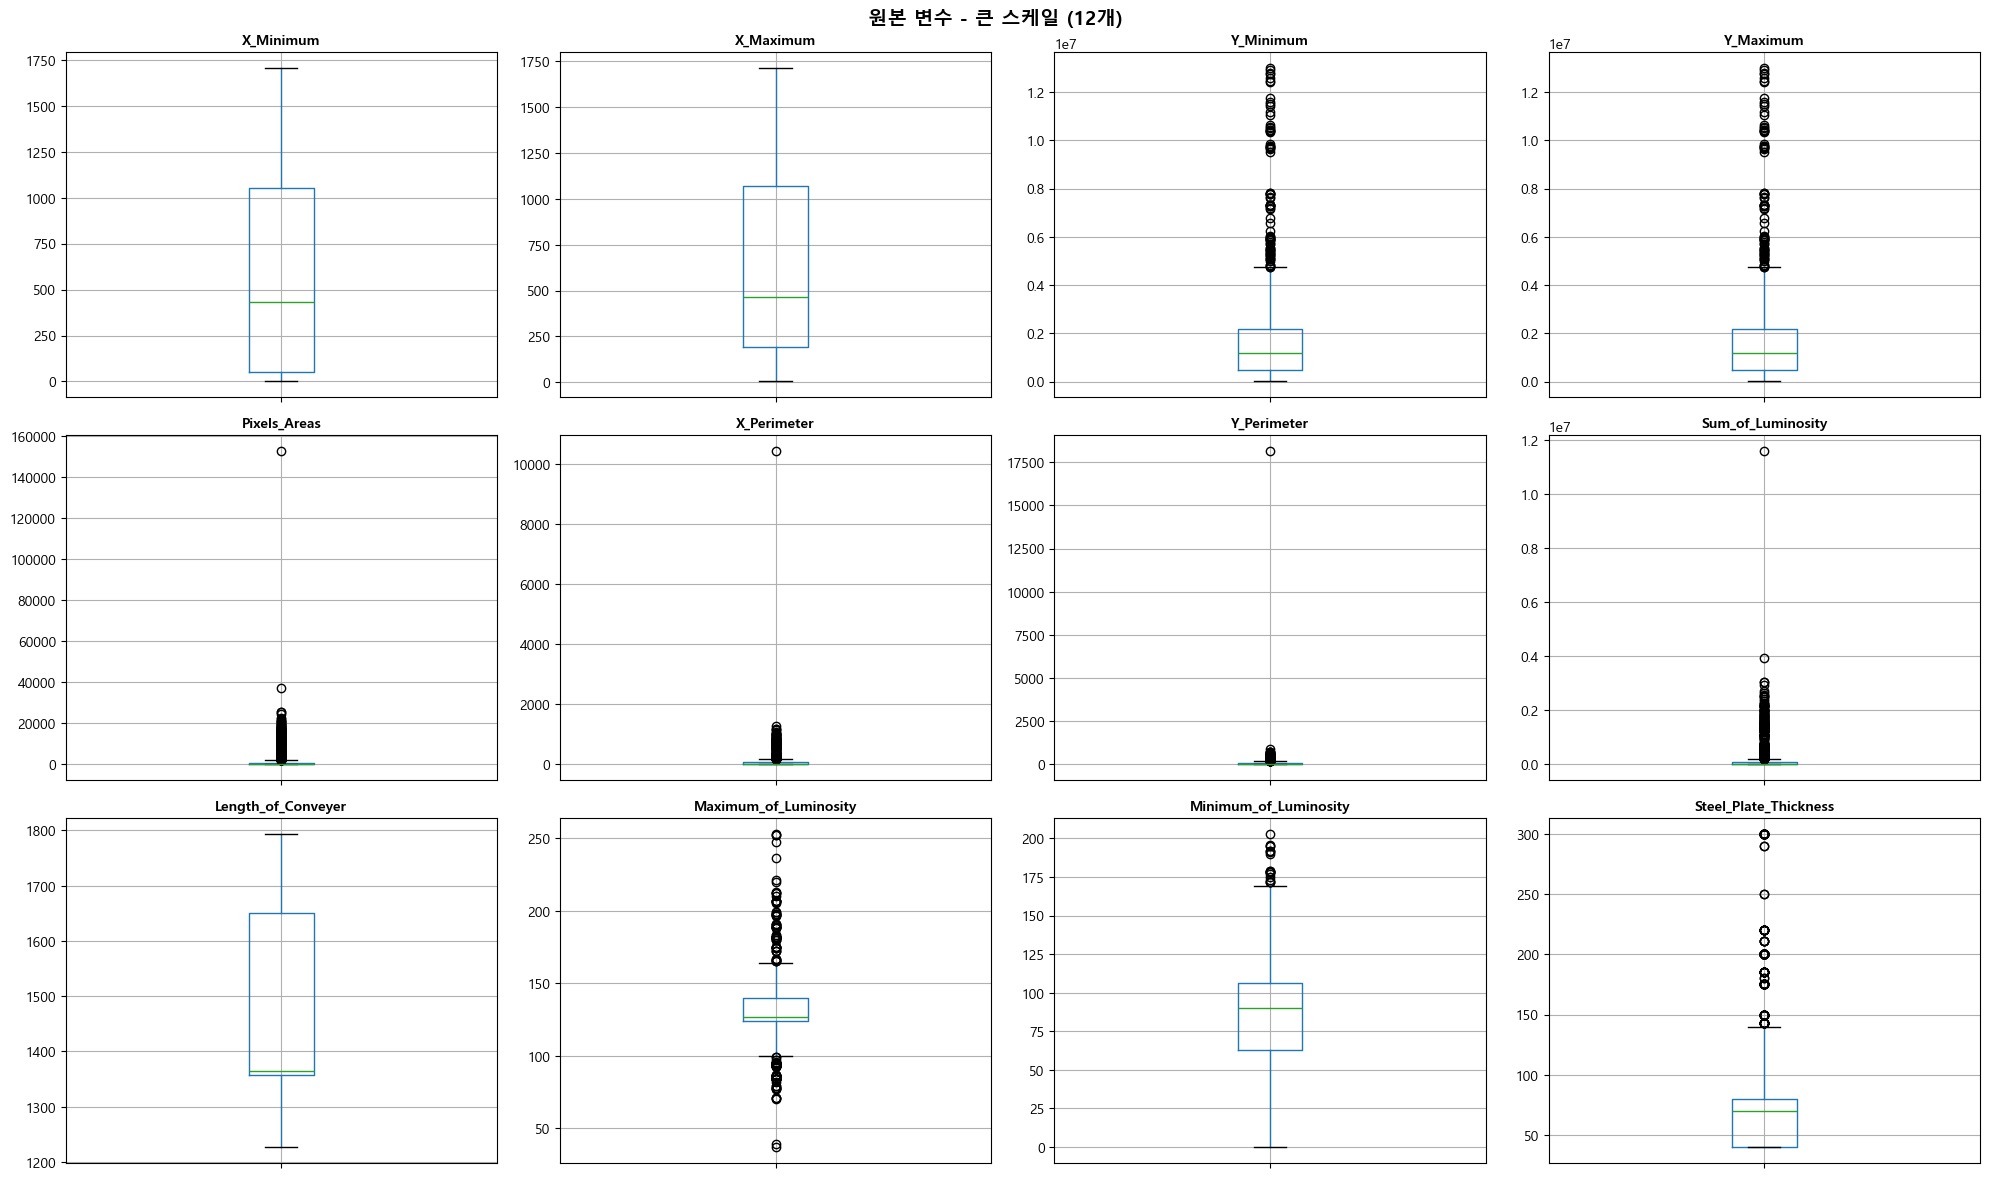

In [ ]:
big_scale = ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
             'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter',
             'Sum_of_Luminosity', 'Length_of_Conveyer',
             'Maximum_of_Luminosity', 'Minimum_of_Luminosity',
             'Steel_Plate_Thickness']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(big_scale):
    features.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('원본 변수 - 큰 스케일 (12개)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

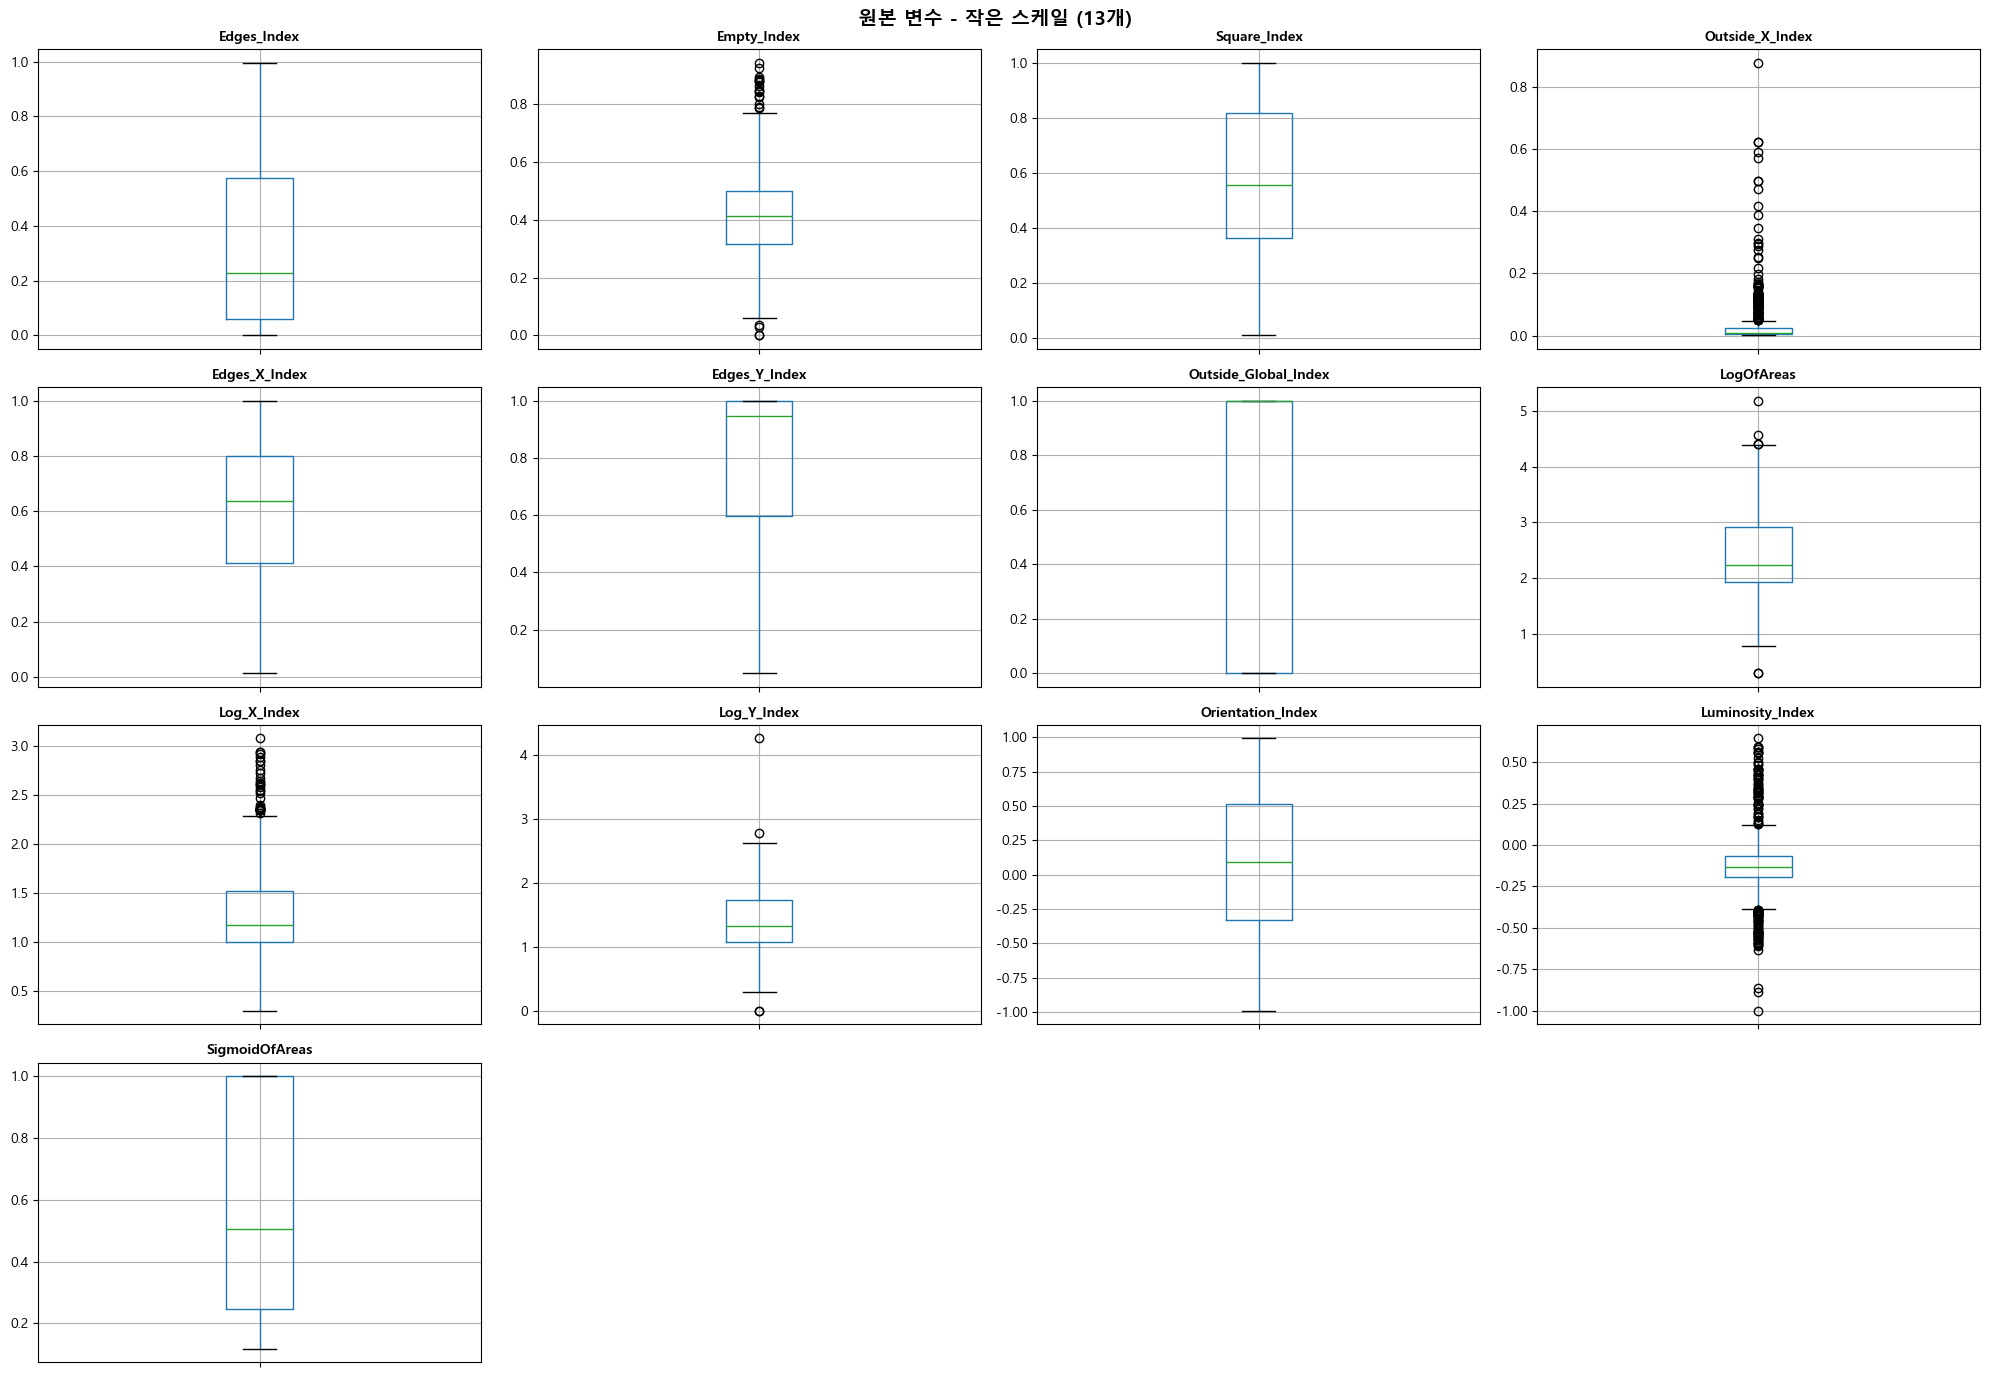

In [ ]:
small_scale = ['Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
               'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index',
               'LogOfAreas', 'Log_X_Index', 'Log_Y_Index',
               'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(small_scale):
    features.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

for idx in range(len(small_scale), 16):
    fig.delaxes(axes[idx])

plt.suptitle('원본 변수 - 작은 스케일 (13개)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

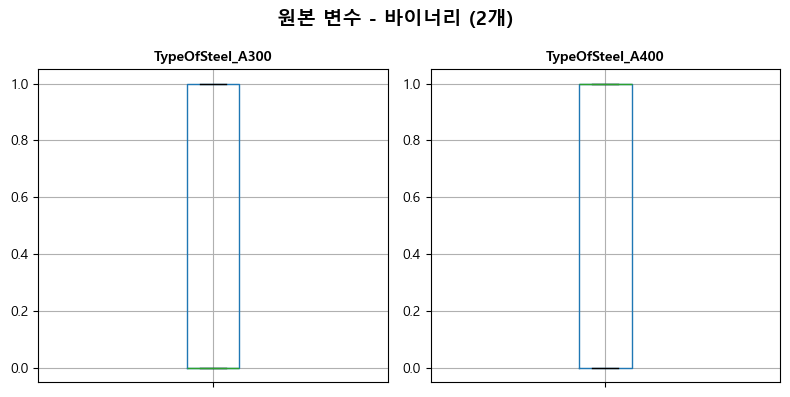

In [ ]:
binary = ['TypeOfSteel_A300', 'TypeOfSteel_A400']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, col in enumerate(binary):
    features.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('원본 변수 - 바이너리 (2개)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

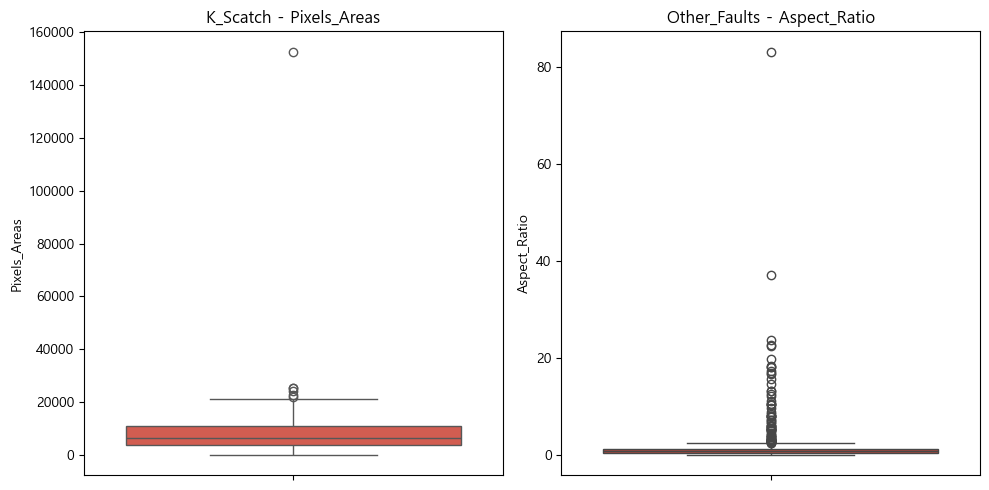

In [ ]:
df['Width'] = df['X_Maximum'] - df['X_Minimum']
df['Height'] = df['Y_Maximum'] - df['Y_Minimum']
df['Aspect_Ratio'] = df['Width'] / (df['Height'] + 1)

# K_Scatch 데이터
k_scratch_df = df[df['FaultType'] == 'K_Scratch']

# Other_Faults 데이터
other_faults_df = df[df['FaultType'] == 'Other_Faults']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 1. K_Scatch - Pixels_Areas
sns.boxplot(
    y=k_scratch_df['Pixels_Areas'],
    ax=ax[0],
    color="#e74c3c"
)
ax[0].set_title('K_Scatch - Pixels_Areas')
ax[0].set_ylabel('Pixels_Areas')

# 2. Other_Faults - Aspect_Ratio
sns.boxplot(
    y=other_faults_df['Aspect_Ratio'],
    ax=ax[1],
    color="#c0392b"
)
ax[1].set_title('Other_Faults - Aspect_Ratio')
ax[1].set_ylabel('Aspect_Ratio')

plt.tight_layout()
plt.show()

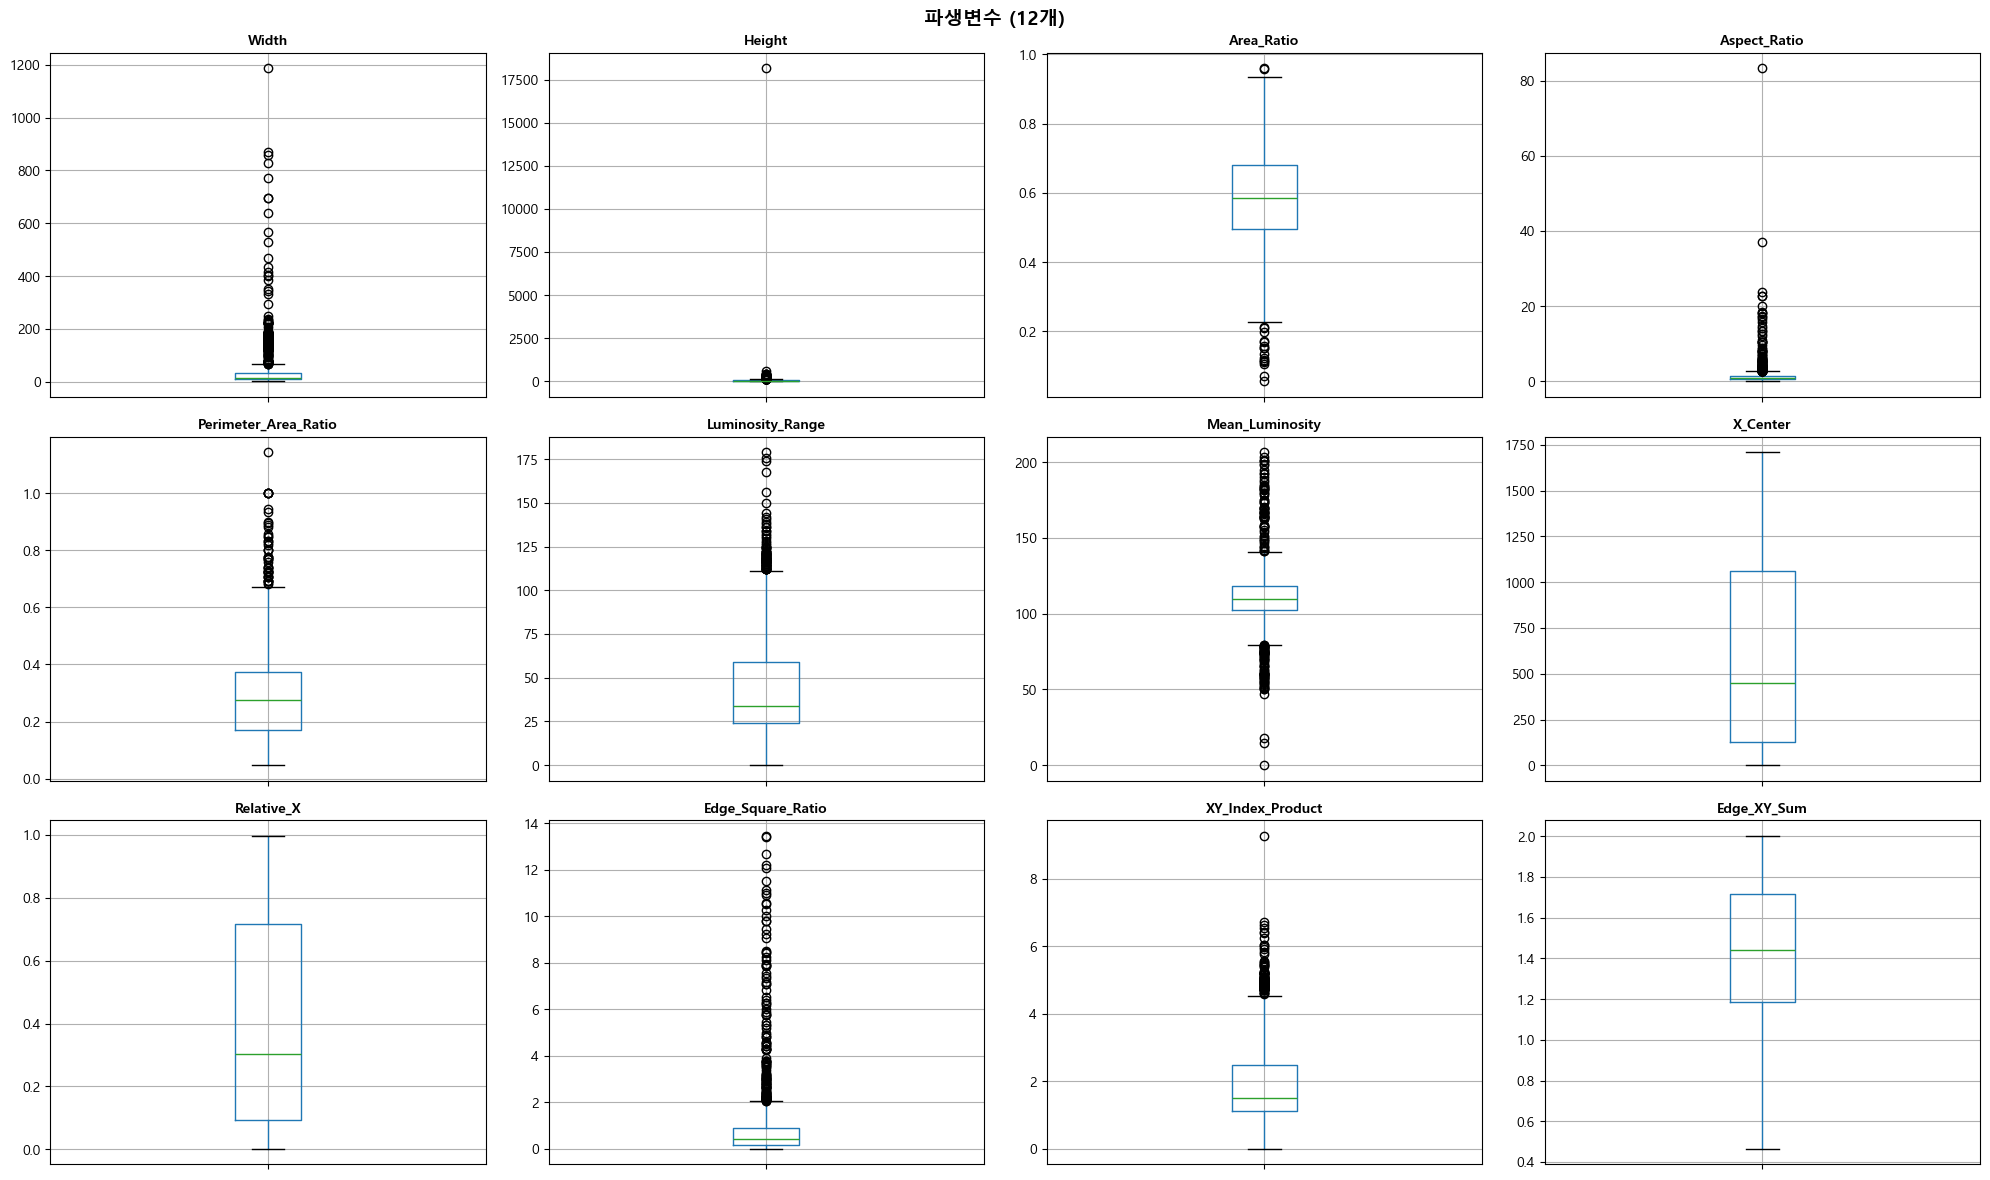

In [ ]:
# 파생변수 목록
derived_cols = ['Width', 'Height', 'Area_Ratio', 'Aspect_Ratio', 'Perimeter_Area_Ratio',
                'Luminosity_Range', 'Mean_Luminosity', 'X_Center', 'Relative_X',
                'Edge_Square_Ratio', 'XY_Index_Product', 'Edge_XY_Sum']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(derived_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('파생변수 (12개)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
all_cols = list(features[features.columns.difference(fault_cols)].columns) + derived_cols

print('=== 변수별 기초 통계 및 극단값 후보 ===\n')
print(f'{"Variable":30s} | {"Min":>12s} | {"Q1":>12s} | {"Median":>12s} | {"Q3":>12s} | {"Max":>12s}')
print('-' * 100)

for col in all_cols:
    if col in binary:
        continue
    q1 = features[features.columns.difference(fault_cols)][col].quantile(0.25)
    q3 = features[features.columns.difference(fault_cols)][col].quantile(0.75)
    med = features[features.columns.difference(fault_cols)][col].median()
    mn = features[features.columns.difference(fault_cols)][col].min()
    mx = features[features.columns.difference(fault_cols)][col].max()
    print(f'{col:30s} | {mn:12.2f} | {q1:12.2f} | {med:12.2f} | {q3:12.2f} | {mx:12.2f}')

=== 변수별 기초 통계 및 극단값 후보 ===

Variable                       |          Min |           Q1 |       Median |           Q3 |          Max
----------------------------------------------------------------------------------------------------
Area_Ratio                     |         0.06 |         0.50 |         0.59 |         0.68 |         0.96
Aspect_Ratio                   |         0.01 |         0.47 |         0.86 |         1.33 |        83.25
Edge_Square_Ratio              |         0.00 |         0.15 |         0.43 |         0.91 |        13.45
Edge_XY_Sum                    |         0.46 |         1.18 |         1.44 |         1.71 |         2.00
Edges_Index                    |         0.00 |         0.06 |         0.23 |         0.57 |         1.00
Edges_X_Index                  |         0.01 |         0.41 |         0.64 |         0.80 |         1.00
Edges_Y_Index                  |         0.05 |         0.60 |         0.95 |         1.00 |         1.00
Empty_Index            

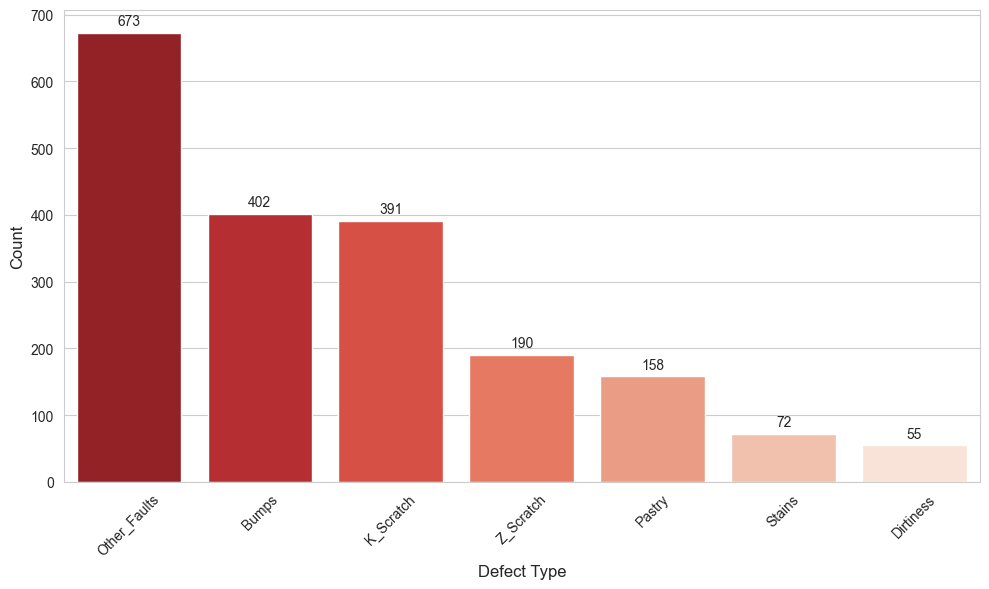

In [ ]:
# 결함 유형별 개수 계산
defect_counts = df['FaultType'].value_counts().sort_values(ascending=False)

# 그래프 스타일
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=defect_counts.index,
    y=defect_counts.values,
    palette="Reds_r"
)

# 막대 위에 개수 표시
for i, v in enumerate(defect_counts.values):
    ax.text(
        i,
        v + max(defect_counts.values) * 0.01,
        str(v),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Defect Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
position_vars = [
    'X_Minimum', 'X_Maximum',
    'Y_Minimum', 'Y_Maximum',
    'X_Center', 'Y_Center',
    'Outside_Global_Index'
]

area_vars = [
    'Pixels_Areas',
    'SigmoidOfAreas',
    'LogOfAreas',
    'Log_X_Index',
    'Log_Y_Index'
]

shape_vars = [
    'Edges_Index',
    'Empty_Index',
    'Square_Index',
    'Y_Perimeter',
    'X_Perimeter',
    'Edges_X_Index',
    'Edges_Y_Index',
    'Orientation_Index'
]

brightness_vars = [
    'Minimum_of_Luminosity',
    'Maximum_of_Luminosity',
    'Luminosity_Index',
    'X_Range',
    'Sum_of_Luminosity'
]

etc_vars = [
    'Steel_Plate_Thickness',
    'Length_of_Conveyer',
    'TypeOfSteel_A400',
    'TypeOfSteel_A300'
]

<!-- ### 베이스라인 모델 -->

In [ ]:
# 타겟 변환
X = features.copy()
le = LabelEncoder()
y = le.fit_transform(targets.idxmax(axis=1))

print(f'Features shape: {features.shape}')
print(f'컬럼 수: {features.shape[1]}개')

Features shape: (1941, 40)
컬럼 수: 40개


In [ ]:
print(f'원본 데이터: {features.shape[0]}건, {features.shape[1]}개 변수')
print(f'\n클래스 분포:')
for i, name in enumerate(le.classes_):
    cnt = (y == i).sum()
    print(f'  {i} → {name:15s}: {cnt:4d}건 ({cnt/len(y)*100:5.1f}%)')

원본 데이터: 1941건, 40개 변수

클래스 분포:
  0 → Bumps          :  402건 ( 20.7%)
  1 → Dirtiness      :   55건 (  2.8%)
  2 → K_Scratch      :  391건 ( 20.1%)
  3 → Other_Faults   :  673건 ( 34.7%)
  4 → Pastry         :  158건 (  8.1%)
  5 → Stains         :   72건 (  3.7%)
  6 → Z_Scratch      :  190건 (  9.8%)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {X_train.shape[0]}건, {X_train.shape[1]}개 변수')
print(f'Test:  {X_test.shape[0]}건')

Train: 1552건, 40개 변수
Test:  389건


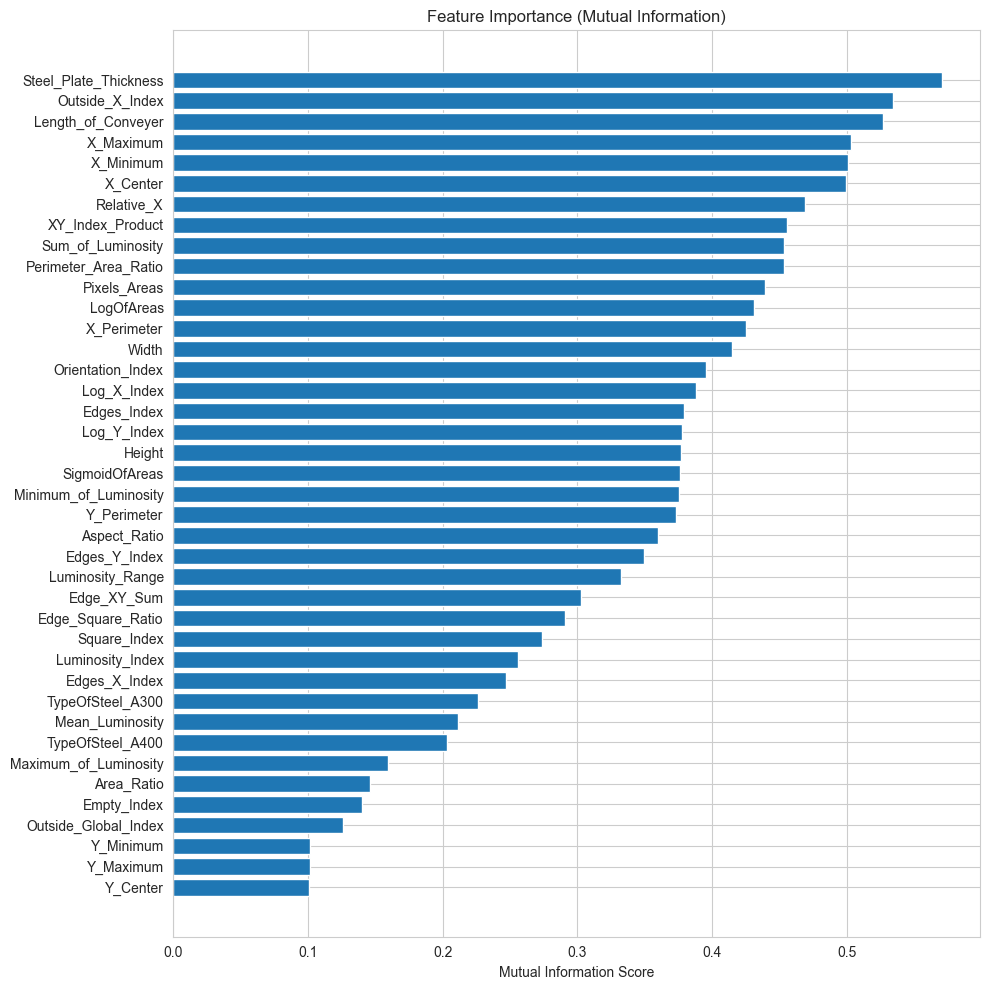


상위 15개 변수:
              Feature  MI_Score
Steel_Plate_Thickness  0.570377
      Outside_X_Index  0.534602
   Length_of_Conveyer  0.526953
            X_Maximum  0.503277
            X_Minimum  0.501239
             X_Center  0.499498
           Relative_X  0.469118
     XY_Index_Product  0.455735
    Sum_of_Luminosity  0.453614
 Perimeter_Area_Ratio  0.453178
         Pixels_Areas  0.438913
           LogOfAreas  0.431061
          X_Perimeter  0.424988
                Width  0.414791
    Orientation_Index  0.395263


In [ ]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(mi_df['Feature'], mi_df['MI_Score'])
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance (Mutual Information)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\n상위 15개 변수:')
print(mi_df.head(15).to_string(index=False))

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=3)

# --- Random Forest ---
def rf_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced',
        'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', RandomForestClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- ExtraTrees ---
def et_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight': 'balanced',
        'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', ExtraTreesClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- XGBoost ---
def xgb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'eval_metric': 'mlogloss', 'verbosity': 0, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', XGBClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- LightGBM ---
def lgbm_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'num_leaves': trial.suggest_int('num_leaves', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'class_weight': 'balanced',
        'verbose': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', LGBMClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- GradientBoosting ---
def gb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', GradientBoostingClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()


# --- 전체 실행 ---
studies = {}
objectives = {
    'RandomForest': rf_obj,
    'ExtraTrees': et_obj,
    'XGBoost': xgb_obj,
    'LightGBM': lgbm_obj,
    'GradientBoosting': gb_obj,
}

for name, obj in objectives.items():
    print(f'\n{name} 튜닝 중...')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(obj, n_trials=150, show_progress_bar=True)
    studies[name] = study
    print(f'{name} 최적 CV F1-Macro = {study.best_value:.4f}')

print('\n=== Optuna 튜닝 결과 ===')
for name, study in studies.items():
    print(f'  {name:20s}: {study.best_value:.4f}')

[I 2026-05-08 01:28:16,626] A new study created in memory with name: no-name-bc40a00d-f687-4320-89bb-dc30fdf0b920



RandomForest 튜닝 중...


Best trial: 0. Best value: 0.763033:   1%|          | 1/150 [00:05<13:24,  5.40s/it]

[I 2026-05-08 01:28:22,028] Trial 0 finished with value: 0.7630325007670784 and parameters: {'n_estimators': 250, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 0.5, 'criterion': 'gini'}. Best is trial 0 with value: 0.7630325007670784.


Best trial: 1. Best value: 0.787981:   1%|▏         | 2/150 [00:11<14:27,  5.86s/it]

...

[I 2026-05-08 03:45:31,045] Trial 147 finished with value: 0.839832205609653 and parameters: {'n_estimators': 373, 'learning_rate': 0.07503782355654265, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 5, 'subsample': 0.9598070681489766, 'max_features': 0.5}. Best is trial 100 with value: 0.8440637831634051.


Best trial: 100. Best value: 0.844064:  99%|█████████▉| 149/150 [1:37:34<00:52, 52.74s/it]

[I 2026-05-08 03:46:27,713] Trial 148 finished with value: 0.8397261367711449 and parameters: {'n_estimators': 420, 'learning_rate': 0.0652579366642356, 'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 4, 'subsample': 0.9710804377804043, 'max_features': 0.5}. Best is trial 100 with value: 0.8440637831634051.


Best trial: 100. Best value: 0.844064: 100%|██████████| 150/150 [1:37:48<00:00, 39.13s/it]

[I 2026-05-08 03:46:41,987] Trial 149 finished with value: 0.8309207013044378 and parameters: {'n_estimators': 340, 'learning_rate': 0.07937311639730847, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 5, 'subsample': 0.9514787989905551, 'max_features': 'log2'}. Best is trial 100 with value: 0.8440637831634051.
GradientBoosting 최적 CV F1-Macro = 0.8441

=== Optuna 튜닝 결과 ===
  RandomForest        : 0.8074
  ExtraTrees          : 0.8135
  XGBoost             : 0.8265
  LightGBM            : 0.8343
  GradientBoosting    : 0.8441


In [ ]:
best_rf = RandomForestClassifier(
    **studies['RandomForest'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_et = ExtraTreesClassifier(
    **studies['ExtraTrees'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_xgb = XGBClassifier(
    **studies['XGBoost'].best_params,
    eval_metric='mlogloss', verbosity=0, random_state=42
)
best_lgbm = LGBMClassifier(
    **studies['LightGBM'].best_params,
    class_weight='balanced', verbose=-1, random_state=42
)
best_gb = GradientBoostingClassifier(
    **studies['GradientBoosting'].best_params,
    random_state=42
)

print('최적 모델 5개 생성 완료')

최적 모델 5개 생성 완료


In [ ]:
# Soft Voting
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    voting='soft', n_jobs=-1
)

# Stacking (메타 모델: LightGBM)
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    final_estimator=LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        verbose=-1, random_state=42
    ),
    cv=skf, n_jobs=-1, passthrough=False
)

# 앙상블 CV 평가
for ens_name, ens_model in [('Voting', voting_model), ('Stacking', stacking_model)]:
    pipe = ImbPipeline([('smote', smote), ('model', ens_model)])
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()
    print(f'{ens_name} CV F1-Macro = {cv_f1:.4f}')

Voting CV F1-Macro = 0.8376
Stacking CV F1-Macro = 0.8170


In [ ]:
smote_final = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote_final.fit_resample(X_train, y_train)

final_models = {
    'RandomForest': best_rf,
    'ExtraTrees': best_et,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm,
    'GradientBoosting': best_gb,
    'Voting': voting_model,
    'Stacking': stacking_model,
}

print('=== 최종 테스트셋 평가 ===\n')
final_results = {}

for name, model in final_models.items():
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt = f1_score(y_test, y_pred, average='weighted')

    final_results[name] = {
        'Accuracy': acc, 'F1-Macro': f1_mac, 'F1-Weighted': f1_wt
    }

final_df = pd.DataFrame(final_results).T.round(4).sort_values('F1-Macro', ascending=False)
print(final_df)

best_name = final_df['F1-Macro'].idxmax()
print(f'\n★ 최종 베스트: {best_name} (F1-Macro = {final_df.loc[best_name, "F1-Macro"]:.4f})')

=== 최종 테스트셋 평가 ===

                  Accuracy  F1-Macro  F1-Weighted
Stacking            0.7892    0.8209       0.7902
XGBoost             0.7841    0.8070       0.7869
ExtraTrees          0.7738    0.8037       0.7766
RandomForest        0.7635    0.8017       0.7669
GradientBoosting    0.7841    0.8007       0.7867
LightGBM            0.7841    0.7970       0.7867
Voting              0.7738    0.7956       0.7768

★ 최종 베스트: Stacking (F1-Macro = 0.8209)


In [ ]:
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'\n=== {best_name} Classification Report ===\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_, digits=4))


=== Stacking Classification Report ===

              precision    recall  f1-score   support

       Bumps     0.7143    0.6790    0.6962        81
   Dirtiness     1.0000    0.9091    0.9524        11
   K_Scratch     0.9740    0.9615    0.9677        78
Other_Faults     0.7194    0.7407    0.7299       135
      Pastry     0.5714    0.6250    0.5970        32
      Stains     1.0000    0.7857    0.8800        14
   Z_Scratch     0.9000    0.9474    0.9231        38

    accuracy                         0.7892       389
   macro avg     0.8399    0.8069    0.8209       389
weighted avg     0.7929    0.7892    0.7902       389



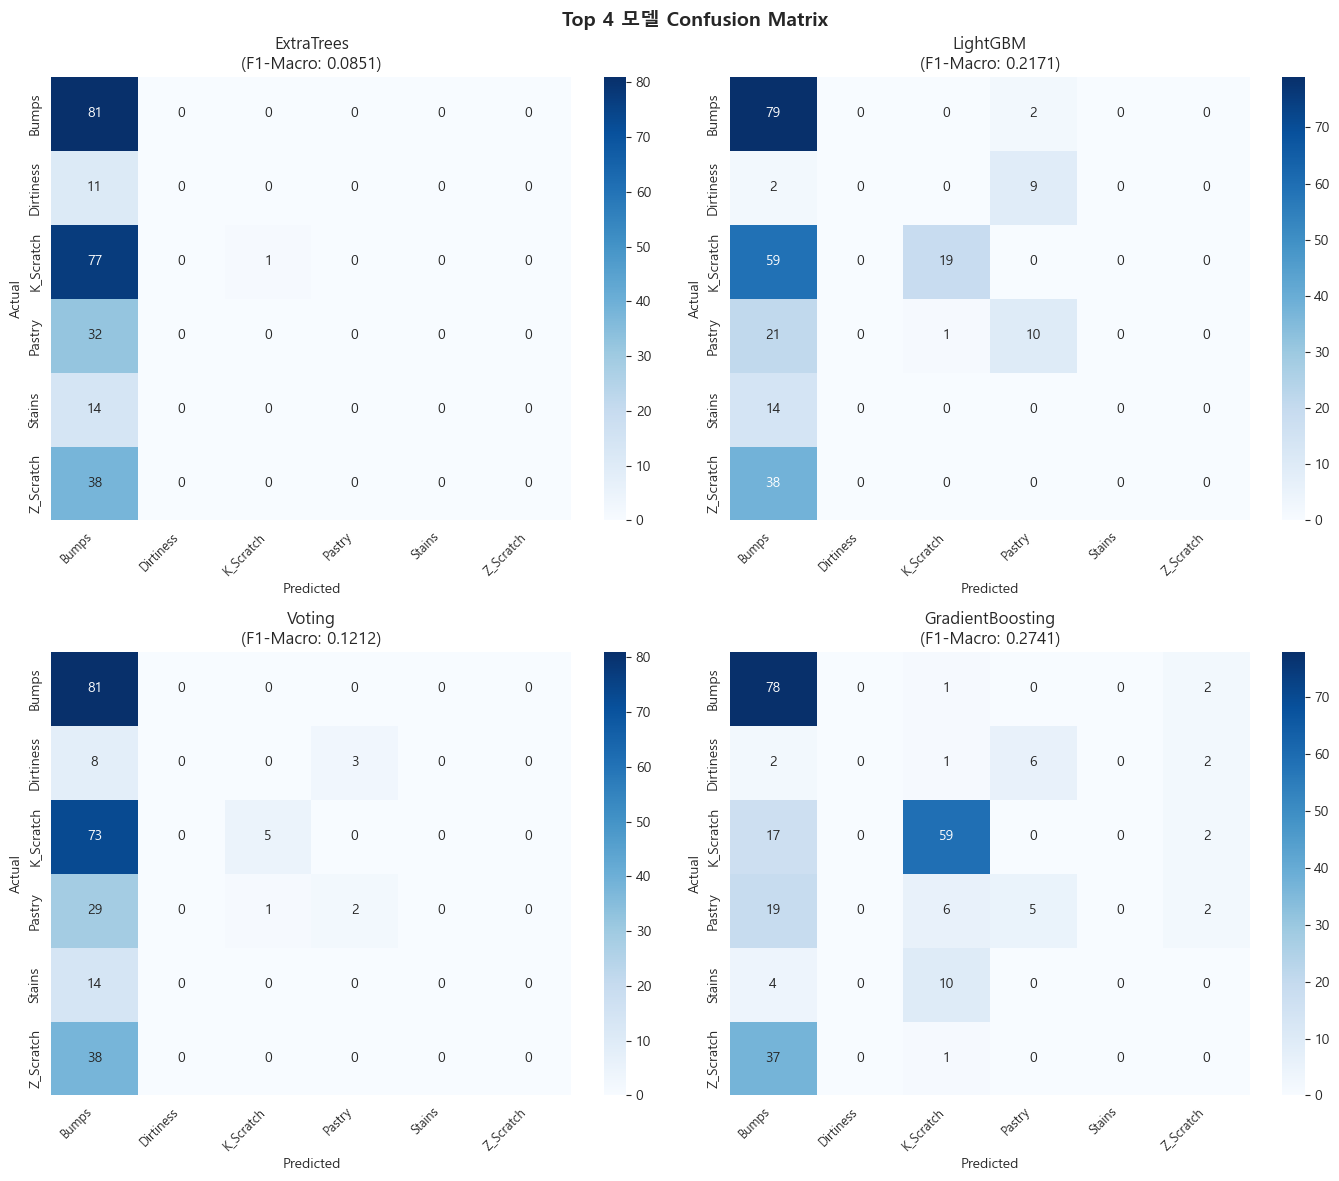

In [ ]:
# 상위 4개 모델만 시각화
top4 = final_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, name in zip(axes, top4):
    model = final_models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\n(F1-Macro: {f1:.4f})', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=9)

plt.suptitle('Top 4 모델 Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

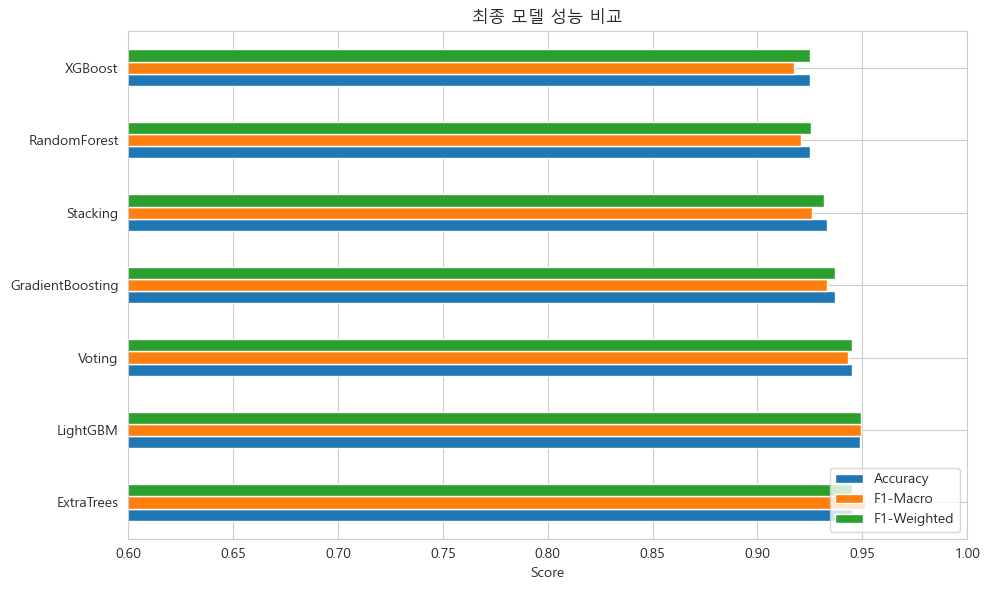


=== 완료 ===
베스트 모델: ExtraTrees
F1-Macro:    0.9513
F1-Weighted: 0.9451
Accuracy:    0.9449


In [ ]:
final_df[['Accuracy', 'F1-Macro', 'F1-Weighted']].plot(
    kind='barh', figsize=(10, 6)
)
plt.xlabel('Score')
plt.title('최종 모델 성능 비교')
plt.xlim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n=== 완료 ===')
print(f'베스트 모델: {best_name}')
print(f'F1-Macro:    {final_df.loc[best_name, "F1-Macro"]:.4f}')
print(f'F1-Weighted: {final_df.loc[best_name, "F1-Weighted"]:.4f}')
print(f'Accuracy:    {final_df.loc[best_name, "Accuracy"]:.4f}')

<!-- ### 1차 모델링 -->

In [ ]:
y_full = le.fit_transform(targets.idxmax(axis=1))

print(f'원본 데이터: {features.shape[0]}건, {features.shape[1]}개 변수')
print(f'\n클래스 분포:')
for i, name in enumerate(le.classes_):
    cnt = (y_full == i).sum()
    print(f'  {i} → {name:15s}: {cnt:4d}건 ({cnt/len(y_full)*100:5.1f}%)')

원본 데이터: 1941건, 40개 변수

클래스 분포:
  0 → Bumps          :  402건 ( 20.7%)
  1 → Dirtiness      :   55건 (  2.8%)
  2 → K_Scratch      :  391건 ( 20.1%)
  3 → Other_Faults   :  673건 ( 34.7%)
  4 → Pastry         :  158건 (  8.1%)
  5 → Stains         :   72건 (  3.7%)
  6 → Z_Scratch      :  190건 (  9.8%)


In [ ]:
# 행 391: K_Scratch - Pixels_Areas 152,655 / X_Perimeter 10,449 / Y_Perimeter 18,152
#          모든 크기 관련 변수에서 동시에 최극단값 (일반 결함의 약 900배)
# 행 1863: Other_Faults - Aspect_Ratio 83.25 (2위 37.06의 2배 이상)
#          높이 3, 폭 333으로 비정상적 형태

remove_idx = [391, 1863]

features_clean = features.drop(index=remove_idx).reset_index(drop=True)
y_clean_full = np.delete(y_full, remove_idx)

print(f'제거 전: {features.shape[0]}건')
print(f'제거 후: {features_clean.shape[0]}건 (제거: {len(remove_idx)}건)')
print(f'\n제거 후 클래스 분포:')
for i, name in enumerate(le.classes_):
    cnt = (y_clean_full == i).sum()
    print(f'  {name:15s}: {cnt:4d}건')

제거 전: 1941건
제거 후: 1939건 (제거: 2건)

제거 후 클래스 분포:
  Bumps          :  402건
  Dirtiness      :   55건
  K_Scratch      :  390건
  Other_Faults   :  672건
  Pastry         :  158건
  Stains         :   72건
  Z_Scratch      :  190건


In [ ]:
X = features_clean.copy()

# 1) 기하학적 파생변수
X['Width'] = X['X_Maximum'] - X['X_Minimum']
X['Height'] = X['Y_Maximum'] - X['Y_Minimum']
X['Area_Ratio'] = X['Pixels_Areas'] / (X['Width'] * X['Height'] + 1)
X['Aspect_Ratio'] = X['Width'] / (X['Height'] + 1)
X['Perimeter_Area_Ratio'] = (X['X_Perimeter'] + X['Y_Perimeter']) / (X['Pixels_Areas'] + 1)

# 2) 밝기 파생변수
X['Luminosity_Range'] = X['Maximum_of_Luminosity'] - X['Minimum_of_Luminosity']
X['Mean_Luminosity'] = X['Sum_of_Luminosity'] / (X['Pixels_Areas'] + 1)

# 3) 위치 파생변수
X['X_Center'] = (X['X_Minimum'] + X['X_Maximum']) / 2
X['Relative_X'] = X['X_Center'] / (X['Length_of_Conveyer'] + 1)

# 4) 인덱스 조합 파생변수
X['Edge_Square_Ratio'] = X['Edges_Index'] / (X['Square_Index'] + 0.01)
X['XY_Index_Product'] = X['Log_X_Index'] * X['Log_Y_Index']
X['Edge_XY_Sum'] = X['Edges_X_Index'] + X['Edges_Y_Index']

# 다중공선성 높은 변수 제거
X.drop(columns=['TypeOfSteel_A400', 'Y_Maximum'], inplace=True)

y = y_clean_full

print(f'피처 엔지니어링 후: {X.shape[1]}개 변수')

피처 엔지니어링 후: 38개 변수


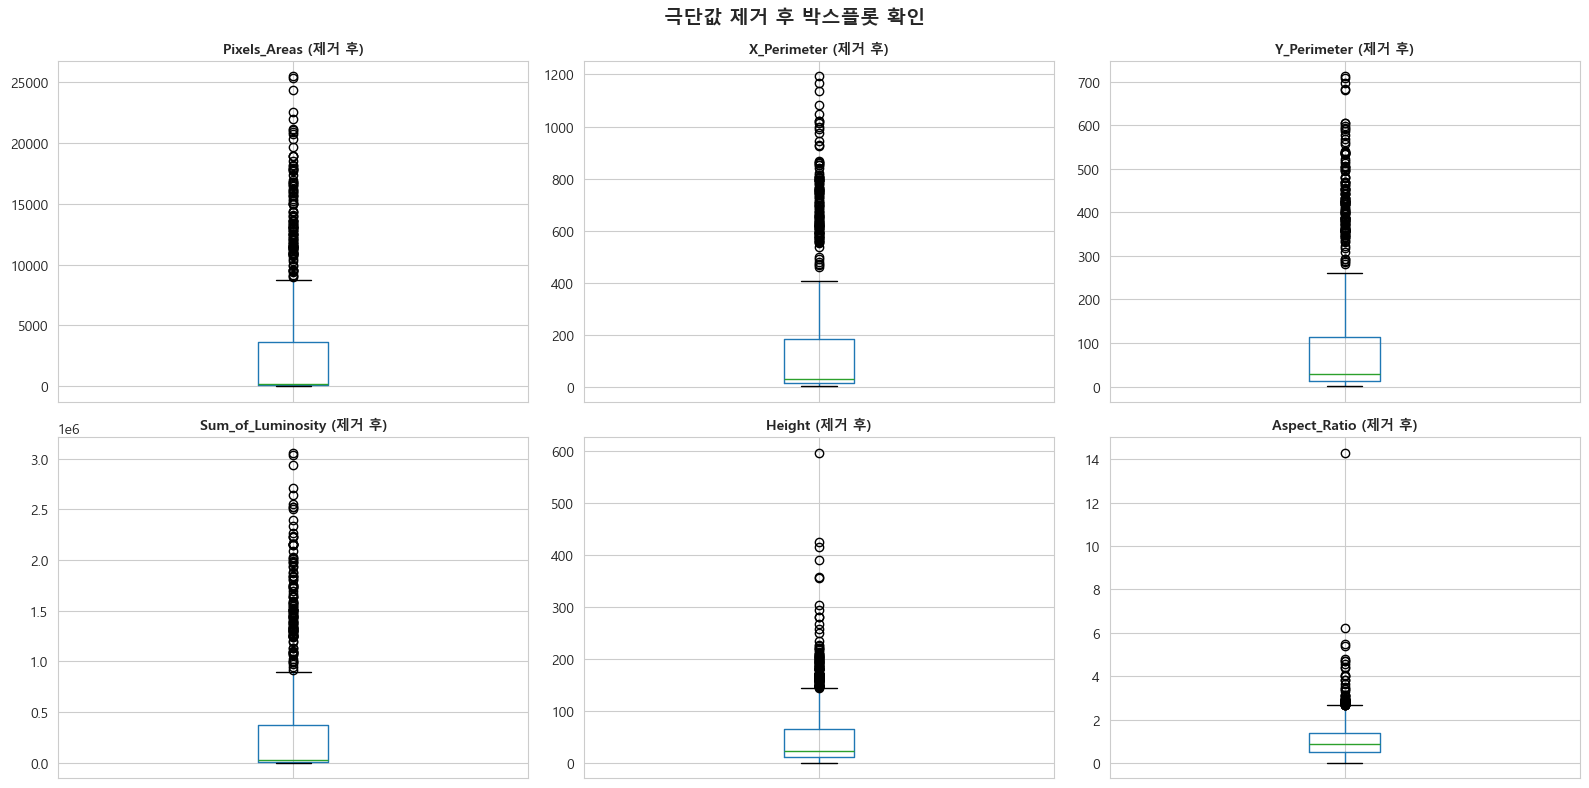

In [ ]:
check_vars = ['Pixels_Areas', 'X_Perimeter', 'Y_Perimeter',
              'Sum_of_Luminosity', 'Height', 'Aspect_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(check_vars):
    X.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col} (제거 후)', fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('극단값 제거 후 박스플롯 확인', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'Train: {X_train_scaled.shape[0]}건, {X_train_scaled.shape[1]}개 변수')
print(f'Test:  {X_test_scaled.shape[0]}건')

Train: 1551건, 38개 변수
Test:  388건


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=3)

baseline_pipes = {
    'RandomForest': ImbPipeline([
        ('smote', smote),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42,
                                         class_weight='balanced', n_jobs=-1))
    ]),
    'ExtraTrees': ImbPipeline([
        ('smote', smote),
        ('model', ExtraTreesClassifier(n_estimators=100, random_state=42,
                                       class_weight='balanced', n_jobs=-1))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', smote),
        ('model', XGBClassifier(n_estimators=100, random_state=42,
                                eval_metric='mlogloss', verbosity=0))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', smote),
        ('model', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ]),
    'GradientBoosting': ImbPipeline([
        ('smote', smote),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print('=== 2차 모델 베이스라인 (극단값 제거 + SMOTE, 튜닝 전) ===\n')
baseline_results = {}

for name, pipe in baseline_pipes.items():
    cv = cross_validate(
        pipe, X_train_scaled, y_train, cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )
    baseline_results[name] = {
        'Accuracy': cv['test_accuracy'].mean(),
        'F1-Macro': cv['test_f1_macro'].mean(),
        'F1-Weighted': cv['test_f1_weighted'].mean(),
    }
    print(f'{name:20s} F1-Macro={baseline_results[name]["F1-Macro"]:.4f}')

baseline_df = pd.DataFrame(baseline_results).T.round(4)
print(f'\n{baseline_df}')

=== 2차 모델 베이스라인 (극단값 제거 + SMOTE, 튜닝 전) ===

RandomForest         F1-Macro=0.8063
ExtraTrees           F1-Macro=0.7950
XGBoost              F1-Macro=0.8022
LightGBM             F1-Macro=0.8158
GradientBoosting     F1-Macro=0.8192

                  Accuracy  F1-Macro  F1-Weighted
RandomForest        0.7795    0.8063       0.7816
ExtraTrees          0.7698    0.7950       0.7709
XGBoost             0.7827    0.8022       0.7831
LightGBM            0.7924    0.8158       0.7931
GradientBoosting    0.7924    0.8192       0.7929


In [ ]:
# --- Random Forest ---
def rf_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', RandomForestClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- ExtraTrees ---
def et_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', ExtraTreesClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- XGBoost ---
def xgb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'eval_metric': 'mlogloss', 'verbosity': 0, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', XGBClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- LightGBM ---
def lgbm_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'num_leaves': trial.suggest_int('num_leaves', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'class_weight': 'balanced', 'verbose': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', LGBMClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- GradientBoosting ---
def gb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', GradientBoostingClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()


# --- 전체 실행 ---
studies = {}
objectives = {
    'RandomForest': rf_obj,
    'ExtraTrees': et_obj,
    'XGBoost': xgb_obj,
    'LightGBM': lgbm_obj,
    'GradientBoosting': gb_obj,
}

for name, obj in objectives.items():
    print(f'\n{name} 튜닝 중...')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(obj, n_trials=150, show_progress_bar=True)
    studies[name] = study
    print(f'{name} 최적 CV F1-Macro = {study.best_value:.4f}')

print('\n=== Optuna 튜닝 결과 ===')
for name, study in studies.items():
    print(f'  {name:20s}: {study.best_value:.4f}')

[I 2026-05-08 03:57:06,149] A new study created in memory with name: no-name-6ec6db56-a399-4e4e-a960-2ffd1df8895d



RandomForest 튜닝 중...


Best trial: 0. Best value: 0.765822:   1%|          | 1/150 [00:03<07:32,  3.04s/it]

[I 2026-05-08 03:57:09,189] Trial 0 finished with value: 0.765822041494968 and parameters: {'n_estimators': 250, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 0.5, 'criterion': 'gini'}. Best is trial 0 with value: 0.765822041494968.


Best trial: 1. Best value: 0.790428:   1%|▏         | 2/150 [00:07<08:56,  3.62s/it]

...

[I 2026-05-08 07:10:30,971] Trial 147 finished with value: 0.8247048501331717 and parameters: {'n_estimators': 400, 'learning_rate': 0.046225857044182805, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 10, 'subsample': 0.6863071154530025, 'max_features': 'log2'}. Best is trial 114 with value: 0.8427005352107313.


Best trial: 114. Best value: 0.842701:  99%|█████████▉| 149/150 [2:15:12<00:46, 46.61s/it]

[I 2026-05-08 07:11:34,241] Trial 148 finished with value: 0.836945420503533 and parameters: {'n_estimators': 427, 'learning_rate': 0.03100759651828087, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 9, 'subsample': 0.6610370920353844, 'max_features': 0.5}. Best is trial 114 with value: 0.8427005352107313.


Best trial: 114. Best value: 0.842701: 100%|██████████| 150/150 [2:16:13<00:00, 54.49s/it]

[I 2026-05-08 07:12:35,011] Trial 149 finished with value: 0.8360465223607341 and parameters: {'n_estimators': 445, 'learning_rate': 0.034815074657490376, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 10, 'subsample': 0.6130808153814427, 'max_features': 0.5}. Best is trial 114 with value: 0.8427005352107313.
GradientBoosting 최적 CV F1-Macro = 0.8427

=== Optuna 튜닝 결과 ===
  RandomForest        : 0.8110
  ExtraTrees          : 0.8178
  XGBoost             : 0.8232
  LightGBM            : 0.8326
  GradientBoosting    : 0.8427


In [ ]:
best_rf = RandomForestClassifier(
    **studies['RandomForest'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_et = ExtraTreesClassifier(
    **studies['ExtraTrees'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_xgb = XGBClassifier(
    **studies['XGBoost'].best_params,
    eval_metric='mlogloss', verbosity=0, random_state=42
)
best_lgbm = LGBMClassifier(
    **studies['LightGBM'].best_params,
    class_weight='balanced', verbose=-1, random_state=42
)
best_gb = GradientBoostingClassifier(
    **studies['GradientBoosting'].best_params,
    random_state=42
)

# Soft Voting
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    voting='soft', n_jobs=-1
)

# Stacking (메타 모델: LightGBM)
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    final_estimator=LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        verbose=-1, random_state=42
    ),
    cv=skf, n_jobs=-1, passthrough=False
)

# 앙상블 CV 평가
for ens_name, ens_model in [('Voting', voting_model), ('Stacking', stacking_model)]:
    pipe = ImbPipeline([('smote', smote), ('model', ens_model)])
    cv_f1 = cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()
    print(f'{ens_name} CV F1-Macro = {cv_f1:.4f}')

print('\n최적 모델 + 앙상블 생성 완료')

Voting CV F1-Macro = 0.8360
Stacking CV F1-Macro = 0.8145

최적 모델 + 앙상블 생성 완료


In [ ]:
smote_final = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote_final.fit_resample(X_train_scaled, y_train)

final_models = {
    'RandomForest': best_rf,
    'ExtraTrees': best_et,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm,
    'GradientBoosting': best_gb,
    'Voting': voting_model,
    'Stacking': stacking_model,
}

print('=== 2차 모델 최종 테스트셋 평가 ===\n')
final_results = {}

for name, model in final_models.items():
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt = f1_score(y_test, y_pred, average='weighted')

    final_results[name] = {
        'Accuracy': acc, 'F1-Macro': f1_mac, 'F1-Weighted': f1_wt
    }

final_df = pd.DataFrame(final_results).T.round(4).sort_values('F1-Macro', ascending=False)
print(final_df)

best_name = final_df['F1-Macro'].idxmax()
print(f'\n★ 2차 모델 베스트: {best_name} (F1-Macro = {final_df.loc[best_name, "F1-Macro"]:.4f})')

=== 2차 모델 최종 테스트셋 평가 ===

                  Accuracy  F1-Macro  F1-Weighted
GradientBoosting    0.8196    0.8490       0.8212
Voting              0.7990    0.8413       0.8017
LightGBM            0.8015    0.8364       0.8049
XGBoost             0.7938    0.8319       0.7962
ExtraTrees          0.7990    0.8272       0.8000
Stacking            0.8041    0.8188       0.7979
RandomForest        0.7784    0.8173       0.7809

★ 2차 모델 베스트: GradientBoosting (F1-Macro = 0.8490)


In [ ]:
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'\n=== {best_name} Classification Report ===\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_, digits=4))


=== GradientBoosting Classification Report ===

              precision    recall  f1-score   support

       Bumps     0.7262    0.7625    0.7439        80
   Dirtiness     1.0000    0.9091    0.9524        11
   K_Scratch     0.9737    0.9487    0.9610        78
Other_Faults     0.7778    0.7778    0.7778       135
      Pastry     0.5758    0.5938    0.5846        32
      Stains     1.0000    0.9286    0.9630        14
   Z_Scratch     0.9730    0.9474    0.9600        38

    accuracy                         0.8196       388
   macro avg     0.8609    0.8383    0.8490       388
weighted avg     0.8233    0.8196    0.8212       388



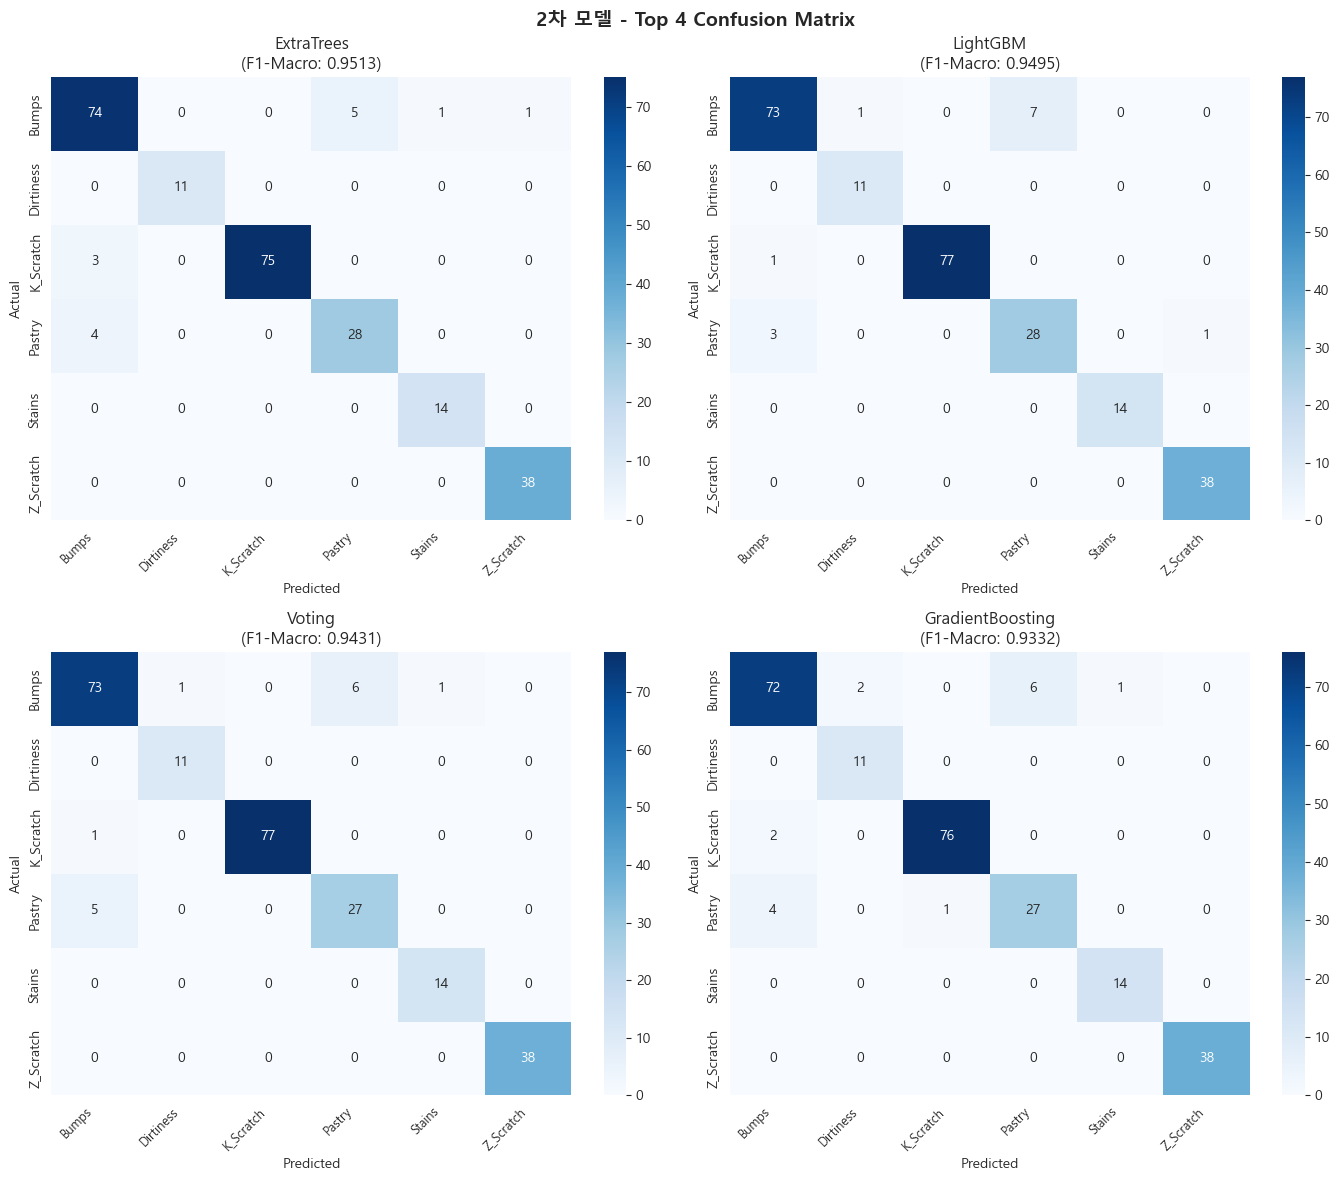

In [ ]:
top4 = final_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, name in zip(axes, top4):
    model = final_models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\n(F1-Macro: {f1:.4f})', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=9)

plt.suptitle('2차 모델 - Top 4 Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

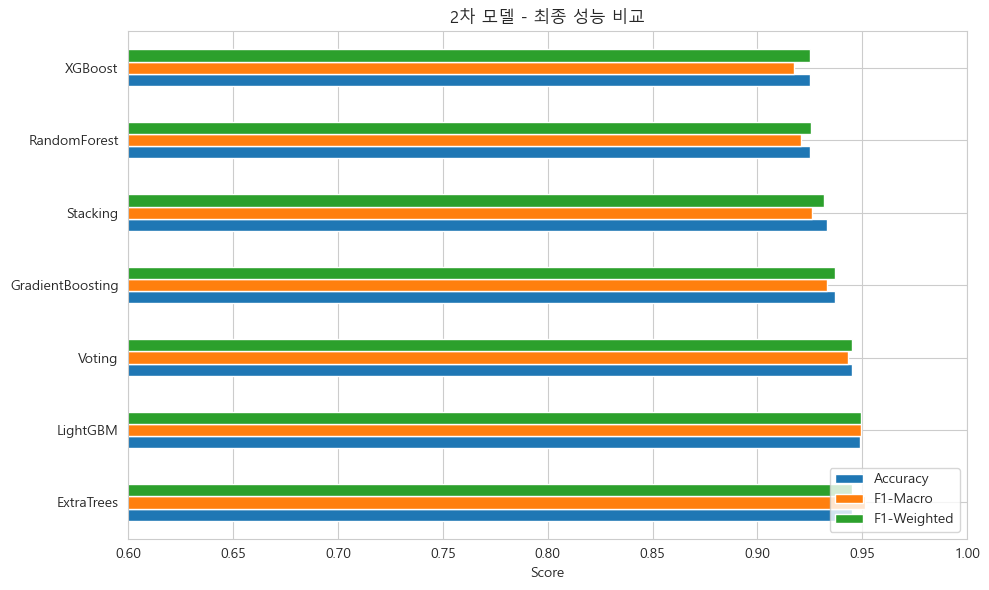


=== 2차 모델 완료 ===
베스트 모델: ExtraTrees
F1-Macro:    0.9513
F1-Weighted: 0.9451
Accuracy:    0.9449


In [ ]:
final_df[['Accuracy', 'F1-Macro', 'F1-Weighted']].plot(
    kind='barh', figsize=(10, 6)
)
plt.xlabel('Score')
plt.title('2차 모델 - 최종 성능 비교')
plt.xlim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n=== 2차 모델 완료 ===')
print(f'베스트 모델: {best_name}')
print(f'F1-Macro:    {final_df.loc[best_name, "F1-Macro"]:.4f}')
print(f'F1-Weighted: {final_df.loc[best_name, "F1-Weighted"]:.4f}')
print(f'Accuracy:    {final_df.loc[best_name, "Accuracy"]:.4f}')

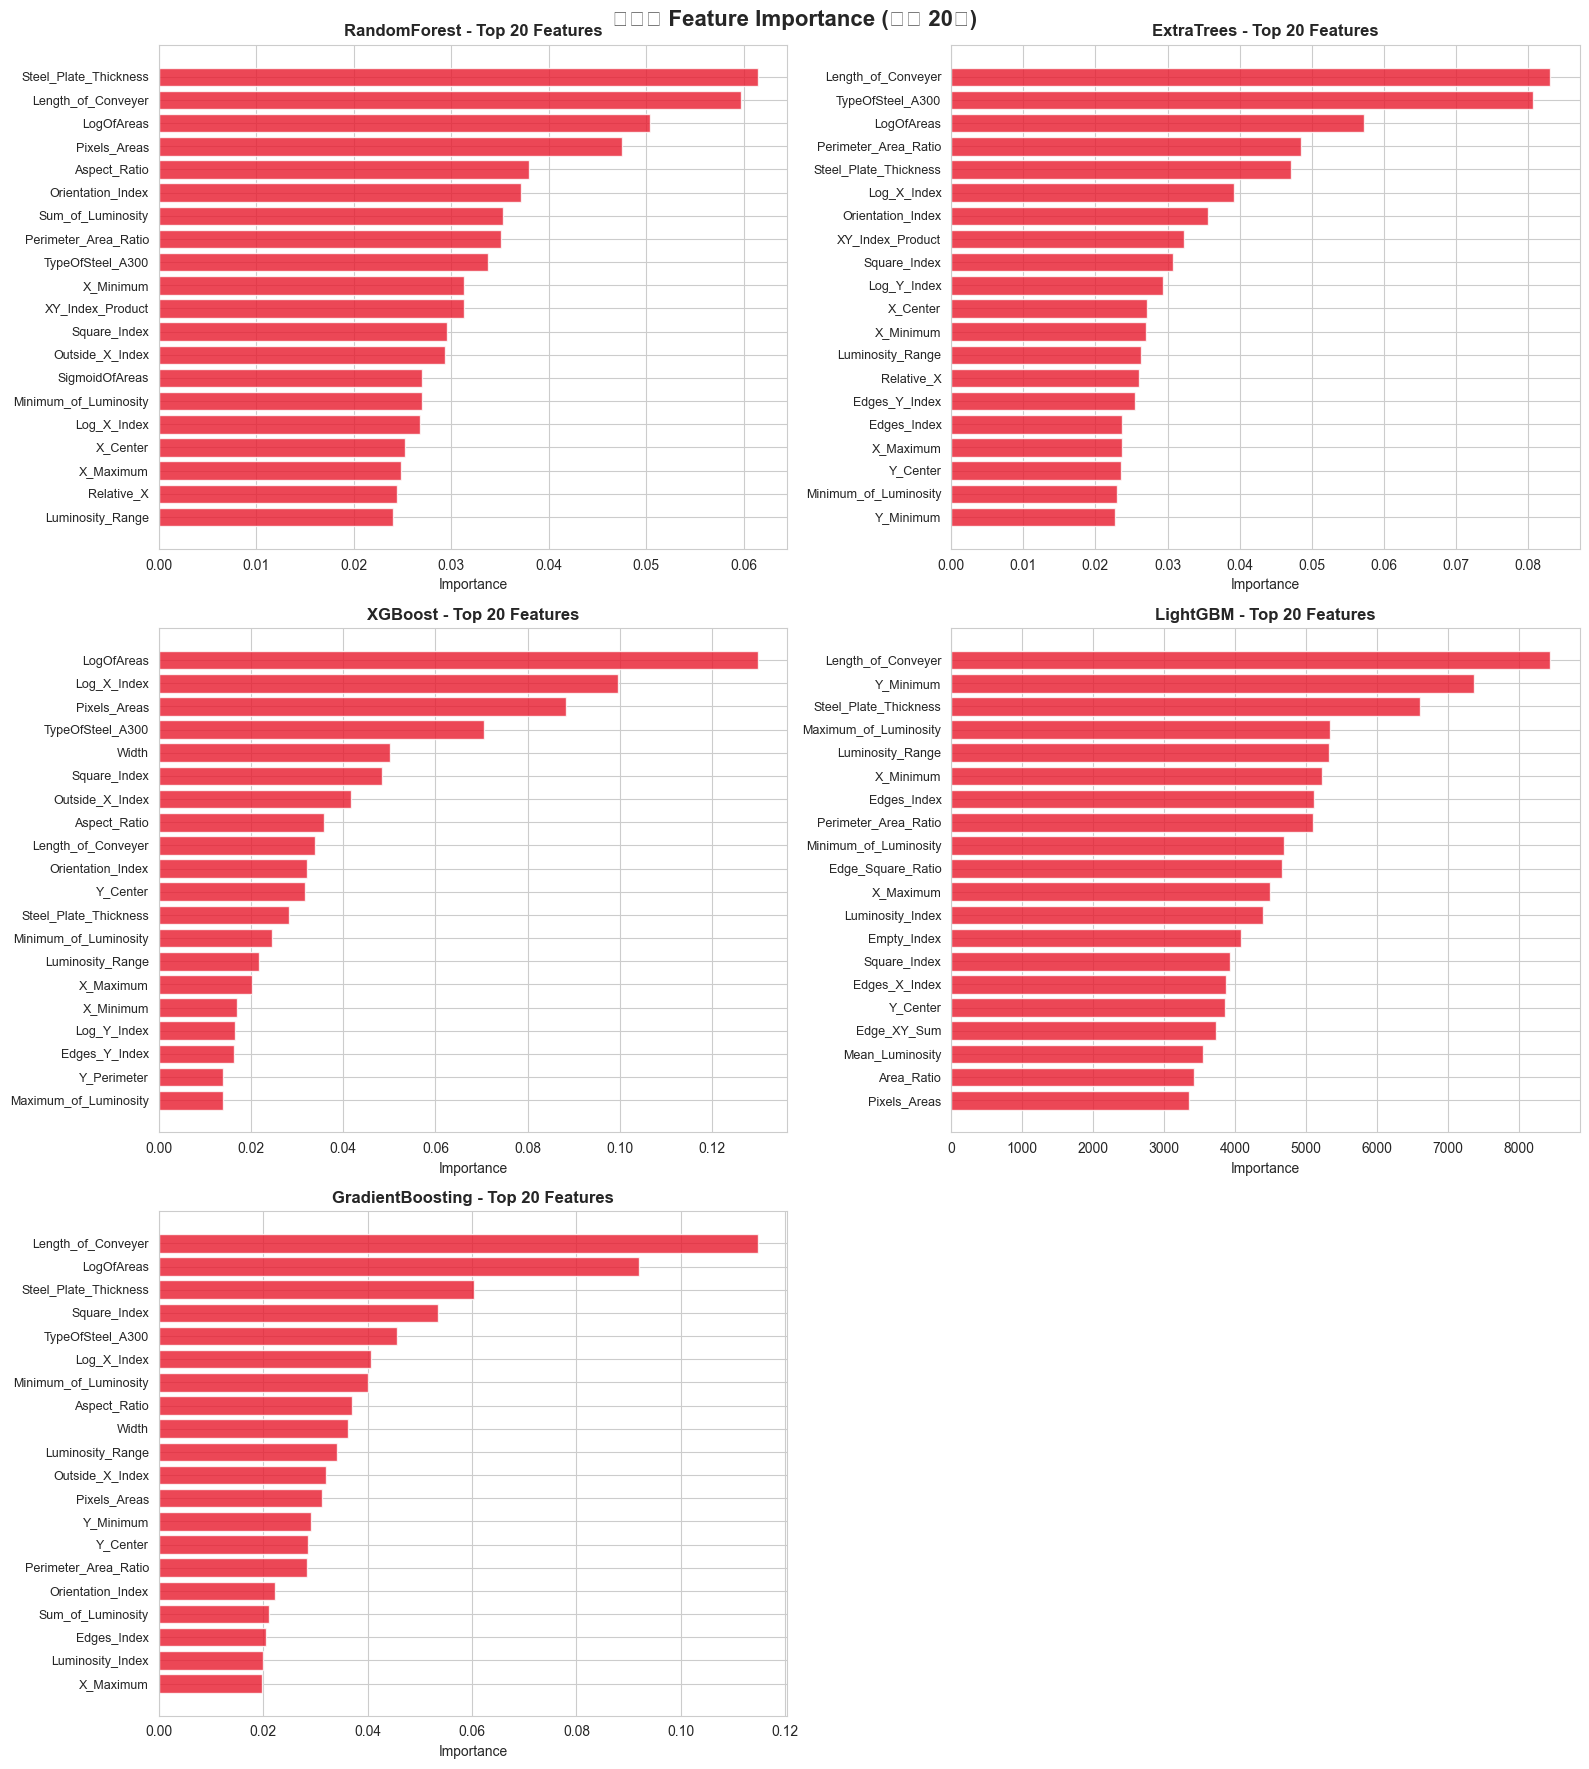

=== 모델 평균 Feature Importance Top 15 ===

                            Mean
Length_of_Conveyer     1688.6583
Y_Minimum              1475.4170
Steel_Plate_Thickness  1320.8394
Maximum_of_Luminosity  1067.6124
Luminosity_Range       1064.8213
X_Minimum              1047.0181
Edges_Index            1023.4142
Perimeter_Area_Ratio   1020.6246
Minimum_of_Luminosity   937.4229
Edge_Square_Ratio       932.6107
X_Maximum               898.8177
Luminosity_Index        880.2127
Empty_Index             816.4099
Square_Index            787.0325
Edges_X_Index           774.4093


In [ ]:
# ==============================================================
# Feature Importance 시각화 (단일 모델 5종 비교)
# ==============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

importance_models = {
    'RandomForest': best_rf,
    'ExtraTrees': best_et,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm,
    'GradientBoosting': best_gb,
}

feature_names = X_train_scaled.columns

for ax, (name, model) in zip(axes, importance_models.items()):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[-20:]  # 상위 20개

    ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='#E8192C', alpha=0.8)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(feature_names[sorted_idx], fontsize=9)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} - Top 20 Features', fontsize=12, fontweight='bold')

# 빈 서브플롯 제거
fig.delaxes(axes[5])

plt.suptitle('모델별 Feature Importance (상위 20개)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5개 모델 평균 중요도 종합
all_importances = pd.DataFrame({
    name: pd.Series(model.feature_importances_, index=feature_names)
    for name, model in importance_models.items()
})
all_importances['Mean'] = all_importances.mean(axis=1)
top15 = all_importances.sort_values('Mean', ascending=False).head(15)

print('=== 모델 평균 Feature Importance Top 15 ===\n')
print(top15[['Mean']].round(4).to_string())

<!-- ### 기타 결함 제거 -->

In [ ]:
selected_cols = [

    # 기본 변수
    'X_Minimum',
    'X_Maximum',
    'Y_Minimum',
    'Pixels_Areas',
    'X_Perimeter',
    'Y_Perimeter',
    'Sum_of_Luminosity',
    'Length_of_Conveyer',
    'Maximum_of_Luminosity',
    'Minimum_of_Luminosity',
    'Steel_Plate_Thickness',
    'TypeOfSteel_A300',
    # 기하학 파생변수
    'Width',
    'Height',
    'Area_Ratio',
    'Aspect_Ratio',
    'Perimeter_Area_Ratio',

    # 밝기 파생변수
    'Luminosity_Range',
    'Mean_Luminosity',

    # 위치 파생변수
    'X_Center',
    'Relative_X',

    # 인덱스 조합 파생변수
    'Edge_Square_Ratio',
    'XY_Index_Product',
    'Edge_XY_Sum'
]

Explained Variance Ratio:
[0.2567392  0.17784768]


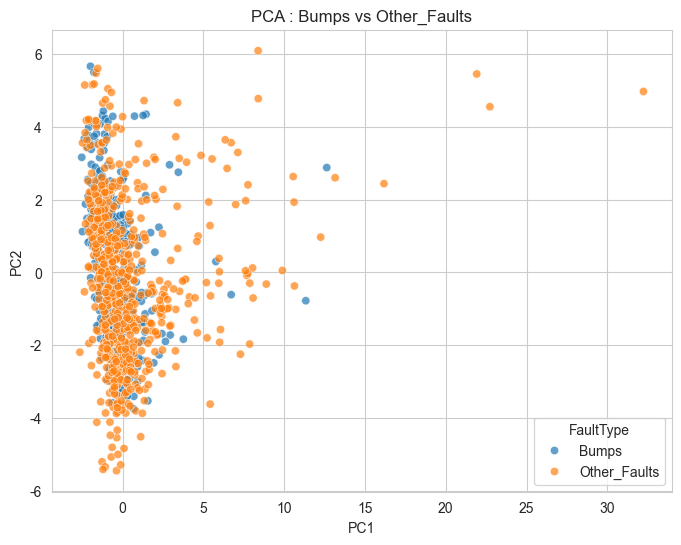

In [ ]:
target_cols = [
    'Pastry', 'Z_Scratch', 'K_Scratch', 'Stains',
    'Dirtiness', 'Bumps', 'Other_Faults'
]

df['FaultType'] = df[target_cols].idxmax(axis=1)

df_bo = df[
    (df['FaultType'] == 'Bumps') |
    (df['FaultType'] == 'Other_Faults')
][selected_cols + ['FaultType']].copy()

# feature / target 분리
X_bo = df_bo.drop(columns='FaultType')
y_bo = df_bo['FaultType']

# scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bo)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# dataframe 생성
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'FaultType': y_bo.values
})

# explained variance 출력
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# 시각화
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='FaultType',
    alpha=0.7
)

plt.title('PCA : Bumps vs Other_Faults')
plt.show()

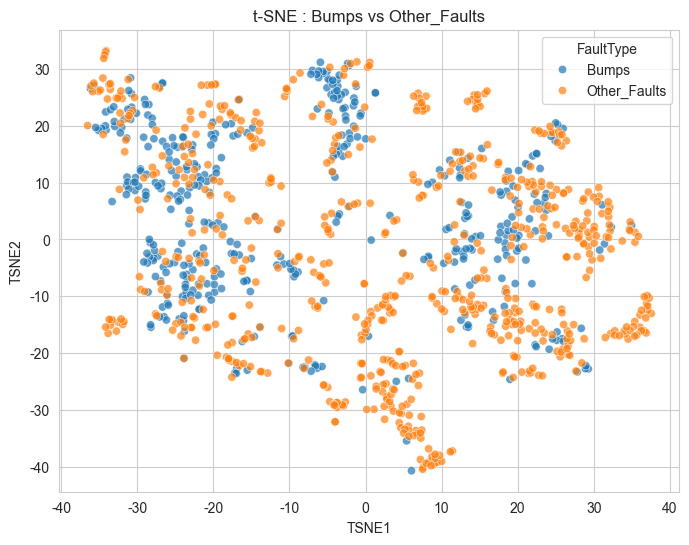

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# dataframe 생성
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'FaultType': y_bo.values
})

# 시각화
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='FaultType',
    alpha=0.7
)

plt.title('t-SNE : Bumps vs Other_Faults')
plt.show()

In [ ]:
class Derived_Variable(BaseEstimator, TransformerMixin):
    def fit(self, df, y=None):
        return self
        # self : 실행 중인 객체 자신을 이용(함수를 활용하는 것과 동시에 데이터 저장
    def transform(self, df):
        #수행할 전처리 단계를 아래쪽에 표시(return 필수)
        df['Width'] = df['X_Maximum'] - df['X_Minimum']
        df['Height'] = df['Y_Maximum'] - df['Y_Minimum']

        df["SteelType"]=df["TypeOfSteel_A300"]
        df["X_range"]=df["Maximum_of_Luminosity"]-df["Minimum_of_Luminosity"]
        df['Area_Ratio'] = df['Pixels_Areas'] / (df['Width'] * df['Height'] + 1)
        df['Perimeter'] = 2 * (df['Width'] + df['Height'])
        a=df[['Area_Ratio','Perimeter',"aspect_ratio",'lum_density',"shape_complexity","density","area_box","width","Orientation_Index","Empty_Index","Square_Index","Edges_Index","Edges_X_Index","Edges_Y_Index","Length_of_Conveyer","Steel_Plate_Thickness","SteelType","Minimum_of_Luminosity",'Pixels_Areas','LogOfAreas','SigmoidOfAreas']]
        return a

class Derived_nonVa(BaseEstimator, TransformerMixin):
    def fit(self, df, y=None):
        return self
        # self : 실행 중인 객체 자신을 이용(함수를 활용하는 것과 동시에 데이터 저장
    def transform(self, df):
        #수행할 전처리 단계를 아래쪽에 표시(return 필수)
        # =========================
        # 1️⃣ 기본 기하
        # =========================
        df["SteelType"]=df["TypeOfSteel_A300"]
        df['Width']  = df['X_Maximum'] - df['X_Minimum']
        df['Height'] = df['Y_Maximum'] - df['Y_Minimum']
        df['area_box'] = df['Width'] * df['Height']
        df['Area_Ratio'] = df['Pixels_Areas'] / (df['Width'] * df['Height'] + 1)

        # =========================
        # 2️⃣ 밝기
        # =========================
        df['Luminosity_Range'] = df['Maximum_of_Luminosity'] - df['Minimum_of_Luminosity']
        df['Mean_Luminosity'] = df['Sum_of_Luminosity'] / (df['Pixels_Areas'] + 1)
        df['Luminosity_Variation'] = df['Luminosity_Range'] / (df['Mean_Luminosity'] + 1)
        df['Log_Luminosity'] = np.log1p(df['Sum_of_Luminosity'])
        df['lum_contrast_ratio'] = df['Luminosity_Range'] / (df['Mean_Luminosity'] + 1)
        df['Luminosity_Std_Proxy'] = df['Luminosity_Range'] / (df['Mean_Luminosity'] + 1)

        # =========================
        # 3️⃣ 형태
        # =========================
        df['Aspect_Ratio'] = df['Width'] / (df['Height'] + 1)
        df['Perimeter'] = 2 * (df['Width'] + df['Height'])
        df['Compactness'] = df['Pixels_Areas'] / (df['Perimeter']**2 + 1)
        df["Normalized_Perimeter"]=df['Perimeter'] / (df['Width'] + df['Height'])

        # 👉 하나만 선택 (추천)
        df['Shape_Complexity'] = (df['X_Perimeter'] + df['Y_Perimeter']) / (df['Pixels_Areas'] + 1)

        # =========================
        # 4️⃣ Edge 구조
        # =========================
        df['Edge_Balance'] = df['Edges_X_Index'] / (df['Edges_Y_Index'] + 1)
        df['Edge_Dominance'] = np.abs(df['Edges_X_Index'] - df['Edges_Y_Index'])
        df['edge_density'] = df['Edges_Index'] / (df['Pixels_Areas'] + 1)
        df['XY_Index_Product'] = df['Log_X_Index'] * df['Log_Y_Index']

        # =========================
        # 5️⃣ 위치
        # =========================
        df['X_Center'] = (df['X_Minimum'] + df['X_Maximum']) / 2
        df['Y_Center'] = (df['Y_Minimum'] + df['Y_Maximum']) / 2
        df['Relative_X'] = df['X_Center'] / (df['Length_of_Conveyer'] + 1)
        df['Edge_Square_Ratio'] = df['Edges_Index'] / (df['Square_Index'] + 0.01)
        df['Edge_XY_Sum'] = df['Edges_X_Index'] + df['Edges_Y_Index']


        # =========================
        # 6️⃣ 상호작용 (핵심)
        # =========================
        df['Irregular_But_Bump'] = df['Edge_Dominance'] * df['Aspect_Ratio']
        df['Position_Orientation'] = df['Orientation_Index'] * df['Relative_X']
        df['Size_Shape_Interaction'] = df['Pixels_Areas'] * df['Shape_Complexity']
        df['Shape_Deviation'] = 1 - df['Square_Index']
        df['Log_Area_X_Ratio'] = df['LogOfAreas'] / (df['Log_X_Index'] + 0.01)
        df['Perimeter_Area_Ratio'] = (df['X_Perimeter'] + df['Y_Perimeter']) / (df['Pixels_Areas'] + 1)
        df["area_perimeter_ratio"] = df["Pixels_Areas"] / (df["X_Perimeter"] + df["Y_Perimeter"])

        # =========================
        # 7️⃣ 로그 안정화
        # =========================
        df['Log_Aspect'] = np.log1p(df['Aspect_Ratio'])
        a=df
        return a

# target data 초기 조정(결함 종류를 하나의 레이블로 조정)
class Target_ad(BaseEstimator, TransformerMixin):
    from sklearn.preprocessing import LabelEncoder, OneHotEncoder
    def fit(self, df, y=None):
        return self

    def transform(self, df):
        fault_cols = ['Pastry','Z_Scratch','K_Scratch','Stains','Dirtiness','Bumps','Other_Faults']
        df['Faulty'] = df.any(axis=1).astype(int)
        df['FaultType'] = df[fault_cols].idxmax(axis=1)
        return df.drop(fault_cols, axis=1)



# 데이터 레이블링 or Scaling
class Transform_Structure(BaseEstimator, TransformerMixin):
    from sklearn.preprocessing import LabelEncoder, OneHotEncoder
    def fit(self, df, y=None):
        return self
    def transform(self, df):
        le = LabelEncoder()
        df["target_le"] = le.fit_transform(df["FaultType"])
        return df, le.classes_, le.transform(le.classes_)



In [ ]:
# target 초기 조정(결함을 한 칼럼으로 조정)
Target=Target_ad()
y=Target.fit_transform(targets)

# XGB LGBM 용 레이블 인코딩
label=Transform_Structure()
y,a,b=label.fit_transform(y)


Derived_non=Derived_nonVa()
df=Derived_non.fit_transform(df.copy())

df_x = df[[
       'X_Minimum', 'X_Maximum', 'Y_Minimum','Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Maximum_of_Luminosity', 'Length_of_Conveyer'
       , 'Steel_Plate_Thickness', 'Edges_Index',
       'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index',
       'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index',
       'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Minimum_of_Luminosity',
       'Width',
       "SteelType",
        'Area_Ratio',
       'Height',
       'Aspect_Ratio',
       'Perimeter_Area_Ratio',
       'Luminosity_Range',
       'Mean_Luminosity',
       'X_Center',
       'Relative_X',
       'Edge_Square_Ratio',
       'XY_Index_Product',
       'Edge_XY_Sum'


]].copy()

df_y=y["target_le"]
# 데이터 셋 분류
X_train,X_test, Y_train, Y_test= train_test_split(df_x,df_y, test_size=0.3,random_state=42,stratify=y)

In [ ]:
# -------------------------------
# 설정
# -------------------------------
N_SPLITS = 5
RANDOM_STATE = 42

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
f1_scrore_ma=[]
# -------------------------------
# 결과 저장용
# -------------------------------
n = len(df_y)

preds = np.zeros(n)
probas = np.zeros((n, len(np.unique(df_y))))
error_count = np.zeros(n)

# -------------------------------
# CV 반복
# -------------------------------
for train_idx, val_idx in kf.split(df_x, df_y):

    X_train, X_val = df_x.iloc[train_idx], df_x.iloc[val_idx]
    y_train, y_val =df_y.iloc[train_idx], df_y.iloc[val_idx]

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)

    preds[val_idx] = pred
    probas[val_idx] = prob

    # 틀린 경우 count
    error_count[val_idx] += (pred != y_val)
    print(f"f1 score 값: {f1_score(y_val, pred, average='macro' )}")
    f1_scrore_ma.append(f1_score(y_val, pred, average='macro' ))

# -------------------------------
# 분석
# -------------------------------
# 예측 확신도
confidence = np.max(probas, axis=1)

# 1 틀린 샘플
wrong_samples = (preds != df_y)

# 2️ hard samples (틀렸고 + 확신 낮음)
hard_samples = (preds != df_y) & (confidence < 0.6)

# 3️ 반복적으로 틀린 샘플
noisy_candidates = error_count >= 2   # (5-fold 기준)

# -------------------------------
# 결과 데이터프레임
# -------------------------------
result = df_x.copy()
result['target'] = df_y
result['pred'] = preds
result['confidence'] = confidence
result['error_count'] = error_count
result['wrong'] = wrong_samples
result['hard'] = hard_samples
result['noisy_candidate'] = noisy_candidates

# -------------------------------
# 확인
# -------------------------------
print("f1score:",np.mean(f1_scrore_ma))
print("전체 샘플 수:", len(result))
print("틀린 샘플 수:", result['wrong'].sum())
print("hard 샘플 수:", result['hard'].sum())
print("노이즈 후보 수:", result['noisy_candidate'].sum())

f1 score 값: 0.82307633319702
f1 score 값: 0.7907641180492228
f1 score 값: 0.8516628300831277
f1 score 값: 0.8375858112587765
f1 score 값: 0.8240676139752268
f1score: 0.8254313413126747
전체 샘플 수: 1941
틀린 샘플 수: 382
hard 샘플 수: 59
노이즈 후보 수: 0


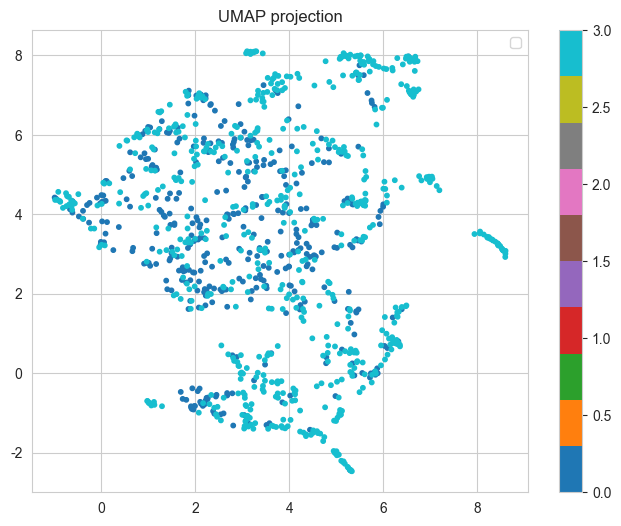

In [ ]:
df_x_03=df_x[df_y.isin([0,3])].copy()
df_y_03=df_y[df_y.isin([0,3])].copy()
X_scaled = StandardScaler().fit_transform(df_x_03)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=df_y_03, cmap='tab10', s=10)
plt.colorbar()
plt.title("UMAP projection")
plt.legend()
plt.show()

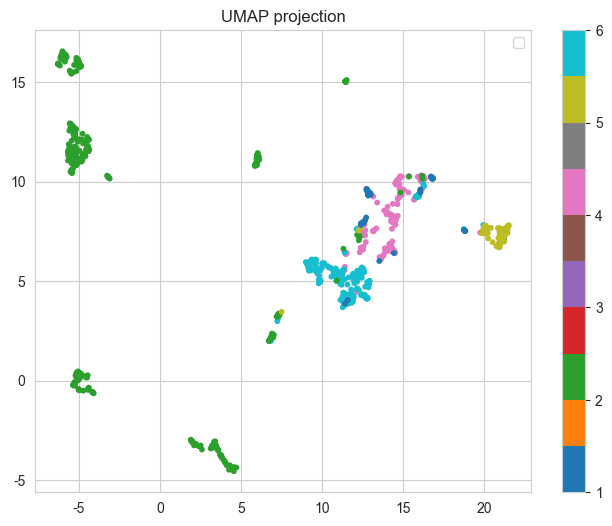

In [ ]:
df_x_12456=df_x[~df_y.isin([0,3])].copy()
df_y_12456=df_y[~df_y.isin([0,3])].copy()
X_scaled = StandardScaler().fit_transform(df_x_12456)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=df_y_12456, cmap='tab10', s=10)
plt.colorbar()
plt.title("UMAP projection")
plt.legend()
plt.show()

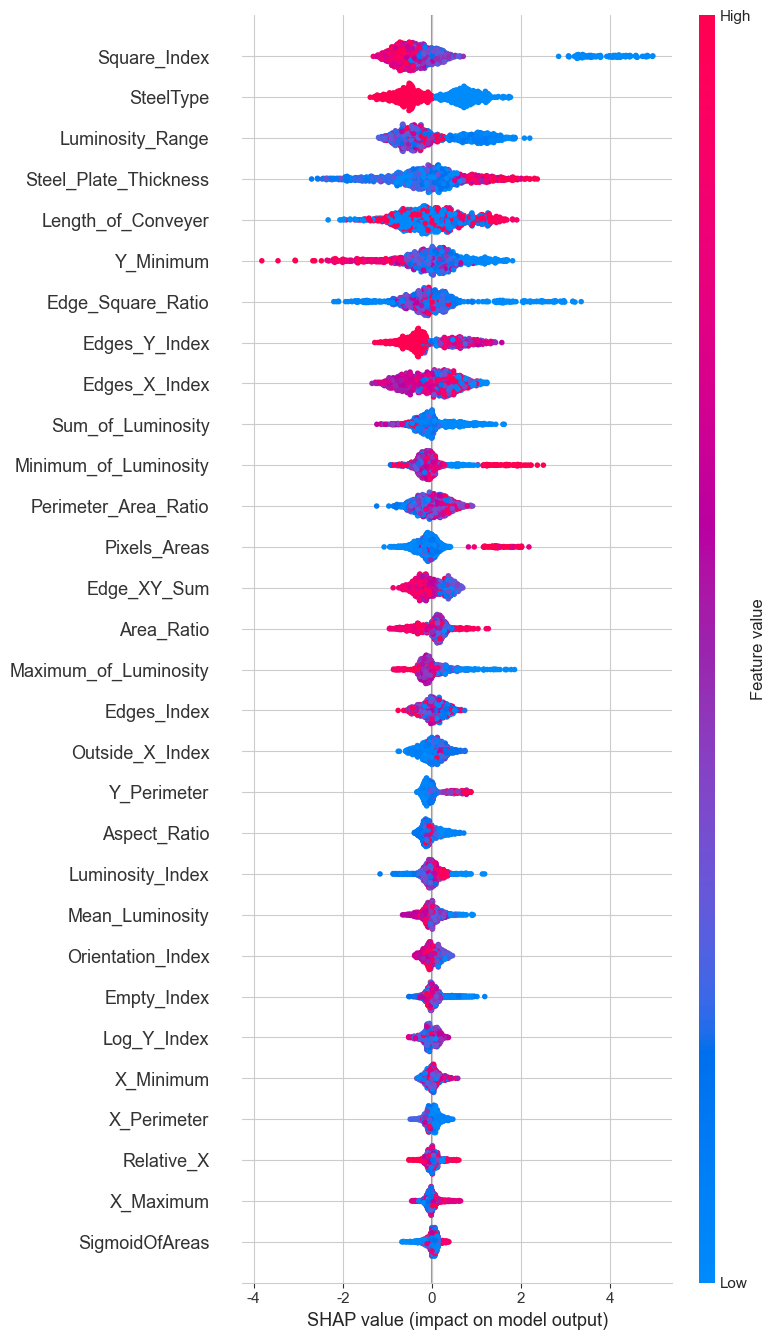

In [ ]:
explainer = shap.TreeExplainer(model)

# SHAP value 계산
shap_values = explainer.shap_values(df_x)
sv=shap_values

# shap 구조 분석.
shap.summary_plot(
    shap_values,
    df_x,
    max_display=30
)


In [ ]:
df_feature = pd.read_csv('steel_plates_faults_features.csv')
df_target = pd.read_csv('steel_plates_faults_targets.csv')

In [ ]:
features = df_feature.copy()
targets = df_target.copy()

In [ ]:
# 타겟 변환
le = LabelEncoder()
y = le.fit_transform(targets.idxmax(axis=1))

print(f'Features shape: {features.shape}')
print(f'컬럼 수: {features.shape[1]}개')

Features shape: (1941, 27)
컬럼 수: 27개


In [ ]:
X = features.copy()

# 1) 기하학적 파생변수
X['Width'] = X['X_Maximum'] - X['X_Minimum']
X['Height'] = X['Y_Maximum'] - X['Y_Minimum']
X['Area_Ratio'] = X['Pixels_Areas'] / (X['Width'] * X['Height'] + 1)
X['Aspect_Ratio'] = X['Width'] / (X['Height'] + 1)
X['Perimeter_Area_Ratio'] = (X['X_Perimeter'] + X['Y_Perimeter']) / (X['Pixels_Areas'] + 1)

# 2) 밝기 파생변수
X['Luminosity_Range'] = X['Maximum_of_Luminosity'] - X['Minimum_of_Luminosity']
X['Mean_Luminosity'] = X['Sum_of_Luminosity'] / (X['Pixels_Areas'] + 1)

# 3) 위치 파생변수
X['X_Center'] = (X['X_Minimum'] + X['X_Maximum']) / 2
X['Relative_X'] = X['X_Center'] / (X['Length_of_Conveyer'] + 1)

# 4) 인덱스 조합 파생변수
X['Edge_Square_Ratio'] = X['Edges_Index'] / (X['Square_Index'] + 0.01)
X['XY_Index_Product'] = X['Log_X_Index'] * X['Log_Y_Index']
X['Edge_XY_Sum'] = X['Edges_X_Index'] + X['Edges_Y_Index']

# 파생변수 목록
derived_cols = ['Width', 'Height', 'Area_Ratio', 'Aspect_Ratio', 'Perimeter_Area_Ratio',
                'Luminosity_Range', 'Mean_Luminosity', 'X_Center', 'Relative_X',
                'Edge_Square_Ratio', 'XY_Index_Product', 'Edge_XY_Sum']

print(f'파생변수 {len(derived_cols)}개 생성 완료')
print(f'전체 X shape: {X.shape}')

파생변수 12개 생성 완료
전체 X shape: (1941, 39)


In [ ]:
le = LabelEncoder()
y_full = le.fit_transform(targets.idxmax(axis=1))

print(f'원본 데이터: {features.shape[0]}건, {features.shape[1]}개 변수')
print(f'\n클래스 분포:')
for i, name in enumerate(le.classes_):
    cnt = (y_full == i).sum()
    print(f'  {i} → {name:15s}: {cnt:4d}건 ({cnt/len(y_full)*100:5.1f}%)')

원본 데이터: 1941건, 27개 변수

클래스 분포:
  0 → Bumps          :  402건 ( 20.7%)
  1 → Dirtiness      :   55건 (  2.8%)
  2 → K_Scratch      :  391건 ( 20.1%)
  3 → Other_Faults   :  673건 ( 34.7%)
  4 → Pastry         :  158건 (  8.1%)
  5 → Stains         :   72건 (  3.7%)
  6 → Z_Scratch      :  190건 (  9.8%)


In [ ]:
# 행 391: K_Scratch - Pixels_Areas 152,655 / X_Perimeter 10,449 / Y_Perimeter 18,152
#          모든 크기 관련 변수에서 동시에 최극단값 (일반 결함의 약 900배)
# 행 1863: Other_Faults - Aspect_Ratio 83.25 (2위 37.06의 2배 이상)
#          높이 3, 폭 333으로 비정상적 형태

remove_idx = [391, 1863]

features_clean = features.drop(index=remove_idx).reset_index(drop=True)
y_clean_full = np.delete(y_full, remove_idx)

print(f'제거 전: {features.shape[0]}건')
print(f'제거 후: {features_clean.shape[0]}건 (제거: {len(remove_idx)}건)')
print(f'\n제거 후 클래스 분포:')
for i, name in enumerate(le.classes_):
    cnt = (y_clean_full == i).sum()
    print(f'  {name:15s}: {cnt:4d}건')

제거 전: 1941건
제거 후: 1939건 (제거: 2건)

제거 후 클래스 분포:
  Bumps          :  402건
  Dirtiness      :   55건
  K_Scratch      :  390건
  Other_Faults   :  672건
  Pastry         :  158건
  Stains         :   72건
  Z_Scratch      :  190건


In [ ]:
X = features_clean.copy()

# 1) 기하학적 파생변수
X['Width'] = X['X_Maximum'] - X['X_Minimum']
X['Height'] = X['Y_Maximum'] - X['Y_Minimum']
X['Area_Ratio'] = X['Pixels_Areas'] / (X['Width'] * X['Height'] + 1)
X['Aspect_Ratio'] = X['Width'] / (X['Height'] + 1)
X['Perimeter_Area_Ratio'] = (X['X_Perimeter'] + X['Y_Perimeter']) / (X['Pixels_Areas'] + 1)

# 2) 밝기 파생변수
X['Luminosity_Range'] = X['Maximum_of_Luminosity'] - X['Minimum_of_Luminosity']
X['Mean_Luminosity'] = X['Sum_of_Luminosity'] / (X['Pixels_Areas'] + 1)

# 3) 위치 파생변수
X['X_Center'] = (X['X_Minimum'] + X['X_Maximum']) / 2
X['Relative_X'] = X['X_Center'] / (X['Length_of_Conveyer'] + 1)

# 4) 인덱스 조합 파생변수
X['Edge_Square_Ratio'] = X['Edges_Index'] / (X['Square_Index'] + 0.01)
X['XY_Index_Product'] = X['Log_X_Index'] * X['Log_Y_Index']
X['Edge_XY_Sum'] = X['Edges_X_Index'] + X['Edges_Y_Index']

# 다중공선성 높은 변수 제거
X.drop(columns=['TypeOfSteel_A400', 'Y_Maximum'], inplace=True)

y = y_clean_full

print(f'피처 엔지니어링 후: {X.shape[1]}개 변수')

피처 엔지니어링 후: 37개 변수


In [ ]:
#데이터 선정
max_val = df['X_Perimeter'].max()

df_xp_clean = df[df['X_Perimeter'] != max_val].copy()
df_clean_y=targets[df['X_Perimeter'] != max_val].copy()


# target 초기 조정(결함을 한 칼럼으로 조정)
Target=Target_ad()
y=Target.fit_transform(df_clean_y)

# XGB LGBM 용 레이블 인코딩
label=Transform_Structure()
y,a,b=label.fit_transform(y)


Derived_non=Derived_nonVa()
df_xp_clean=Derived_non.fit_transform(df_xp_clean.copy())

df_x = df_xp_clean[[
    'X_Minimum', 'X_Maximum', 'Y_Minimum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Maximum_of_Luminosity', 'Length_of_Conveyer'
       , 'Steel_Plate_Thickness', 'Edges_Index',
       'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index',
       'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index',
       'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Minimum_of_Luminosity',
       'Width',
       "SteelType",
        'Area_Ratio',
       'Height',
       'Aspect_Ratio',
       'Perimeter_Area_Ratio',
       'Luminosity_Range',
       'Mean_Luminosity',
       'X_Center',
       'Relative_X',
       'Edge_Square_Ratio',
       'XY_Index_Product',
       'Edge_XY_Sum'


]][y['FaultType'].isin(["Bumps","Other_Faults"])].copy()

df_y=y["target_le"][y['FaultType'].isin(["Bumps","Other_Faults"])]
# 데이터 셋 분류
k={0:0, 3:1}
df_y=df_y.map(k)
df_x = df_x.reset_index(drop=True)
df_y = df_y.reset_index(drop=True)

In [ ]:
# =========================
# Other_Faults 제외
# =========================

fault_names = le.inverse_transform(y_clean_full)

mask = fault_names != 'Other_Faults'

X = X.loc[mask].reset_index(drop=True)
y_label = fault_names[mask]

# 6개 클래스 기준으로 라벨 인코딩 다시 수행
le = LabelEncoder()
y = le.fit_transform(y_label)

print(f'Other_Faults 제외 후 X shape: {X.shape}')
print('\n클래스 분포:')

for i, name in enumerate(le.classes_):
    cnt = (y == i).sum()
    print(f'{i} → {name:15s}: {cnt:4d}건')

Other_Faults 제외 후 X shape: (1267, 37)

클래스 분포:
0 → Bumps          :  402건
1 → Dirtiness      :   55건
2 → K_Scratch      :  390건
3 → Pastry         :  158건
4 → Stains         :   72건
5 → Z_Scratch      :  190건


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'Train: {X_train_scaled.shape[0]}건, {X_train_scaled.shape[1]}개 변수')
print(f'Test:  {X_test_scaled.shape[0]}건')

Train: 1013건, 37개 변수
Test:  254건


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=3)

baseline_pipes = {
    'RandomForest': ImbPipeline([
        ('smote', smote),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42,
                                         class_weight='balanced', n_jobs=-1))
    ]),
    'ExtraTrees': ImbPipeline([
        ('smote', smote),
        ('model', ExtraTreesClassifier(n_estimators=100, random_state=42,
                                       class_weight='balanced', n_jobs=-1))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', smote),
        ('model', XGBClassifier(n_estimators=100, random_state=42,
                                eval_metric='mlogloss', verbosity=0))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', smote),
        ('model', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ]),
    'GradientBoosting': ImbPipeline([
        ('smote', smote),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print('=== 2차 모델 베이스라인 (극단값 제거 + SMOTE, 튜닝 전) ===\n')
baseline_results = {}

for name, pipe in baseline_pipes.items():
    cv = cross_validate(
        pipe, X_train_scaled, y_train, cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )
    baseline_results[name] = {
        'Accuracy': cv['test_accuracy'].mean(),
        'F1-Macro': cv['test_f1_macro'].mean(),
        'F1-Weighted': cv['test_f1_weighted'].mean(),
    }
    print(f'{name:20s} F1-Macro={baseline_results[name]["F1-Macro"]:.4f}')

baseline_df = pd.DataFrame(baseline_results).T.round(4)
print(f'\n{baseline_df}')

=== 2차 모델 베이스라인 (극단값 제거 + SMOTE, 튜닝 전) ===

RandomForest         F1-Macro=0.8731
ExtraTrees           F1-Macro=0.8865
XGBoost              F1-Macro=0.8838
LightGBM             F1-Macro=0.8920
GradientBoosting     F1-Macro=0.8864

                  Accuracy  F1-Macro  F1-Weighted
RandomForest        0.8835    0.8731       0.8842
ExtraTrees          0.8993    0.8865       0.8993
XGBoost             0.9003    0.8838       0.9000
LightGBM            0.9111    0.8920       0.9108
GradientBoosting    0.9013    0.8864       0.9012


In [ ]:
# --- Random Forest ---
def rf_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', RandomForestClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- ExtraTrees ---
def et_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', ExtraTreesClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- XGBoost ---
def xgb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'eval_metric': 'mlogloss', 'verbosity': 0, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', XGBClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- LightGBM ---
def lgbm_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'num_leaves': trial.suggest_int('num_leaves', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'class_weight': 'balanced', 'verbose': -1, 'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', LGBMClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()

# --- GradientBoosting ---
def gb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
    }
    pipe = ImbPipeline([('smote', smote), ('model', GradientBoostingClassifier(**params))])
    return cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()


# --- 전체 실행 ---
studies = {}
objectives = {
    'RandomForest': rf_obj,
    'ExtraTrees': et_obj,
    'XGBoost': xgb_obj,
    'LightGBM': lgbm_obj,
    'GradientBoosting': gb_obj,
}

for name, obj in objectives.items():
    print(f'\n{name} 튜닝 중...')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(obj, n_trials=150, timeout=600, show_progress_bar=True)
    studies[name] = study
    print(f'{name} 최적 CV F1-Macro = {study.best_value:.4f}')

print('\n=== Optuna 튜닝 결과 ===')
for name, study in studies.items():
    print(f'  {name:20s}: {study.best_value:.4f}')

[I 2026-05-08 08:45:47,642] A new study created in memory with name: no-name-83eda18d-f6a0-4b29-81c1-82f92767331c



RandomForest 튜닝 중...


Best trial: 0. Best value: 0.854687:   1%|          | 1/150 [00:01<03:16,  1.32s/it, 1.32/600 seconds]

[I 2026-05-08 08:45:48,962] Trial 0 finished with value: 0.8546867980309967 and parameters: {'n_estimators': 250, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 0.5, 'criterion': 'gini'}. Best is trial 0 with value: 0.8546867980309967.


Best trial: 1. Best value: 0.869958:   1%|▏         | 2/150 [00:03<04:12,  1.70s/it, 3.29/600 seconds]

...

[I 2026-05-08 09:18:15,410] Trial 57 finished with value: 0.8995112637600544 and parameters: {'n_estimators': 104, 'learning_rate': 0.26799458171605595, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 9, 'subsample': 0.7639245155965948, 'max_features': 0.5}. Best is trial 48 with value: 0.9083576552630929.


Best trial: 48. Best value: 0.908358:  39%|███▉      | 59/150 [09:57<09:34,  6.31s/it, 597.72/600 seconds]

[I 2026-05-08 09:18:18,383] Trial 58 finished with value: 0.893782639023 and parameters: {'n_estimators': 126, 'learning_rate': 0.2547492746327298, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 8, 'subsample': 0.7278383809263419, 'max_features': 'sqrt'}. Best is trial 48 with value: 0.9083576552630929.


Best trial: 48. Best value: 0.908358:  40%|████      | 60/150 [10:06<15:09, 10.10s/it, 606.17/600 seconds]

[I 2026-05-08 09:18:26,835] Trial 59 finished with value: 0.8971847608138089 and parameters: {'n_estimators': 142, 'learning_rate': 0.17158440071612716, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 10, 'subsample': 0.6568664852358492, 'max_features': 0.5}. Best is trial 48 with value: 0.9083576552630929.
GradientBoosting 최적 CV F1-Macro = 0.9084

=== Optuna 튜닝 결과 ===
  RandomForest        : 0.8934
  ExtraTrees          : 0.8938
  XGBoost             : 0.9040
  LightGBM            : 0.9063
  GradientBoosting    : 0.9084


In [ ]:
best_rf = RandomForestClassifier(
    **studies['RandomForest'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_et = ExtraTreesClassifier(
    **studies['ExtraTrees'].best_params,
    class_weight='balanced', n_jobs=-1, random_state=42
)
best_xgb = XGBClassifier(
    **studies['XGBoost'].best_params,
    eval_metric='mlogloss', verbosity=0, random_state=42
)
best_lgbm = LGBMClassifier(
    **studies['LightGBM'].best_params,
    class_weight='balanced', verbose=-1, random_state=42
)
best_gb = GradientBoostingClassifier(
    **studies['GradientBoosting'].best_params,
    random_state=42
)

# Soft Voting
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    voting='soft', n_jobs=-1
)

# Stacking (메타 모델: LightGBM)
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf), ('et', best_et), ('xgb', best_xgb),
        ('lgbm', best_lgbm), ('gb', best_gb)
    ],
    final_estimator=LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        verbose=-1, random_state=42
    ),
    cv=skf, n_jobs=-1, passthrough=False
)

# 앙상블 CV 평가
for ens_name, ens_model in [('Voting', voting_model), ('Stacking', stacking_model)]:
    pipe = ImbPipeline([('smote', smote), ('model', ens_model)])
    cv_f1 = cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1).mean()
    print(f'{ens_name} CV F1-Macro = {cv_f1:.4f}')

print('\n최적 모델 + 앙상블 생성 완료')

Voting CV F1-Macro = 0.9064
Stacking CV F1-Macro = 0.8930

최적 모델 + 앙상블 생성 완료


In [ ]:
smote_final = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote_final.fit_resample(X_train_scaled, y_train)

final_models = {
    'RandomForest': best_rf,
    'ExtraTrees': best_et,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm,
    'GradientBoosting': best_gb,
    'Voting': voting_model,
    'Stacking': stacking_model,
}

print('=== 2차 모델 최종 테스트셋 평가 ===\n')
final_results = {}

for name, model in final_models.items():
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt = f1_score(y_test, y_pred, average='weighted')

    final_results[name] = {
        'Accuracy': acc, 'F1-Macro': f1_mac, 'F1-Weighted': f1_wt
    }

final_df = pd.DataFrame(final_results).T.round(4).sort_values('F1-Macro', ascending=False)
print(final_df)

best_name = final_df['F1-Macro'].idxmax()
print(f'\n★ 2차 모델 베스트: {best_name} (F1-Macro = {final_df.loc[best_name, "F1-Macro"]:.4f})')

=== 2차 모델 최종 테스트셋 평가 ===

                  Accuracy  F1-Macro  F1-Weighted
ExtraTrees          0.9449    0.9513       0.9451
LightGBM            0.9488    0.9495       0.9493
Voting              0.9449    0.9431       0.9450
GradientBoosting    0.9370    0.9332       0.9371
Stacking            0.9331    0.9260       0.9318
RandomForest        0.9252    0.9206       0.9256
XGBoost             0.9252    0.9175       0.9252

★ 2차 모델 베스트: ExtraTrees (F1-Macro = 0.9513)


In [ ]:
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'\n=== {best_name} Classification Report ===\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_, digits=4))


=== ExtraTrees Classification Report ===

              precision    recall  f1-score   support

       Bumps     0.3202    1.0000    0.4850        81
   Dirtiness     0.0000    0.0000    0.0000        11
   K_Scratch     1.0000    0.0128    0.0253        78
      Pastry     0.0000    0.0000    0.0000        32
      Stains     0.0000    0.0000    0.0000        14
   Z_Scratch     0.0000    0.0000    0.0000        38

    accuracy                         0.3228       254
   macro avg     0.2200    0.1688    0.0851       254
weighted avg     0.4092    0.3228    0.1624       254



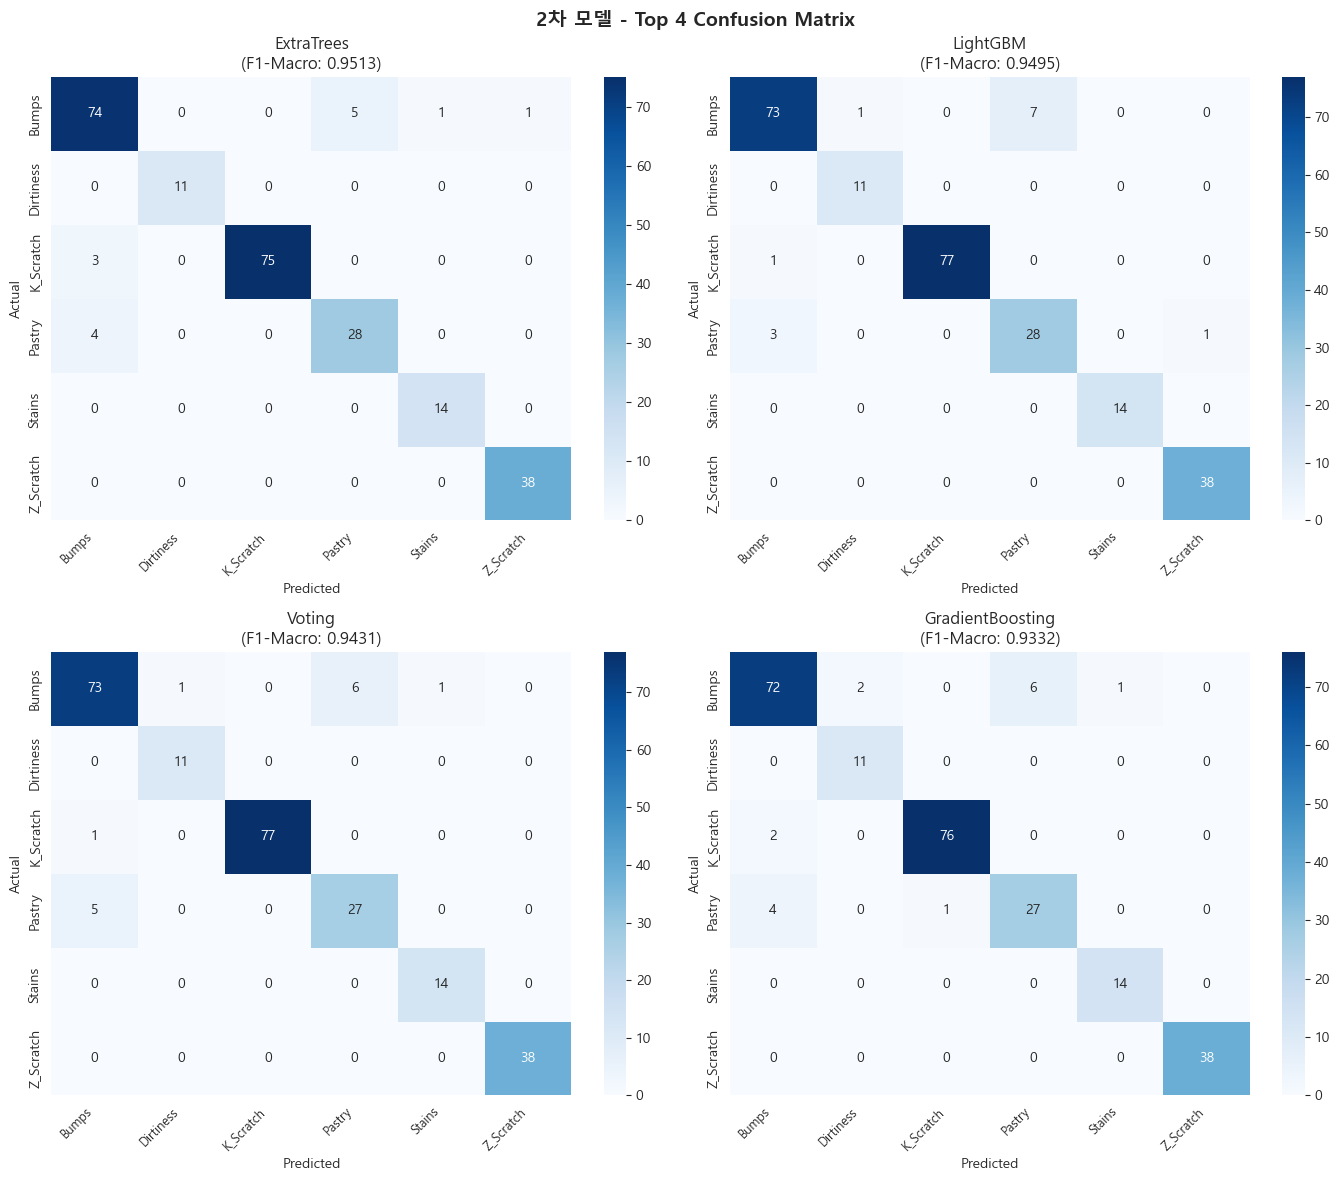

In [ ]:
top4 = final_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, name in zip(axes, top4):
    model = final_models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\n(F1-Macro: {f1:.4f})', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=9)

plt.suptitle('2차 모델 - Top 4 Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

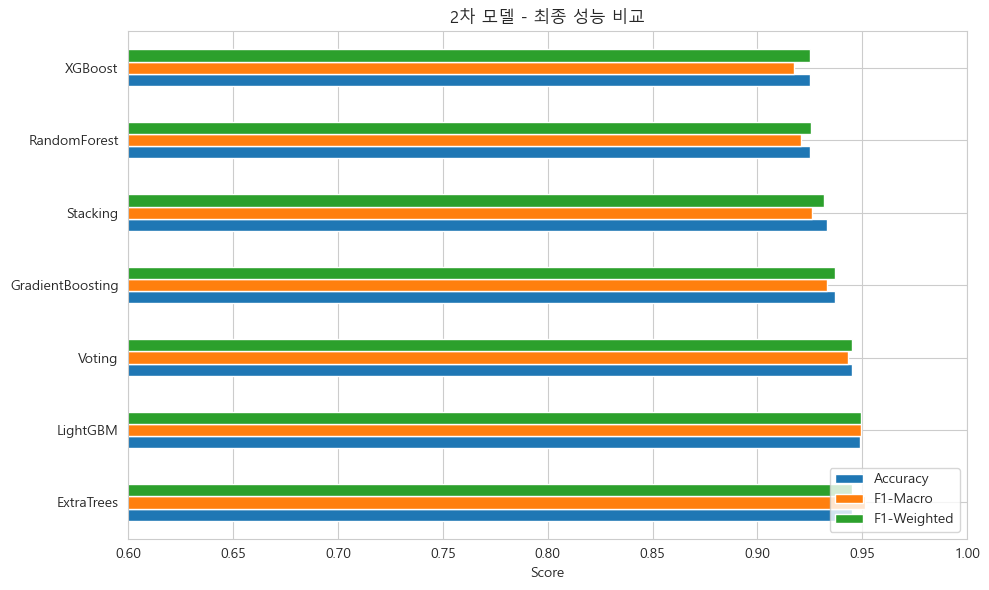


=== 2차 모델 완료 ===
베스트 모델: ExtraTrees
F1-Macro:    0.9513
F1-Weighted: 0.9451
Accuracy:    0.9449


In [ ]:
final_df[['Accuracy', 'F1-Macro', 'F1-Weighted']].plot(
    kind='barh', figsize=(10, 6)
)
plt.xlabel('Score')
plt.title('2차 모델 - 최종 성능 비교')
plt.xlim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n=== 2차 모델 완료 ===')
print(f'베스트 모델: {best_name}')
print(f'F1-Macro:    {final_df.loc[best_name, "F1-Macro"]:.4f}')
print(f'F1-Weighted: {final_df.loc[best_name, "F1-Weighted"]:.4f}')
print(f'Accuracy:    {final_df.loc[best_name, "Accuracy"]:.4f}')